## Dependencias
# Ejecutar este comando para instalar las librerías necesarias
```
penv/Scripts/activate
pip install pandas numpy scikit-learn matplotlib seaborn jinja2
```

In [292]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder # Librería para crear modelos de ML
import sys
import os
import importlib

# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python
sys.path.append(src_path)

# Ahora ya puedes importar
import utils
importlib.reload(utils)  # Forzar recarga si ya se había importado antes

<module 'utils' from 'c:\\Users\\j\\Desktop\\Joaquín\\Clase\\Master\\VSC\\TFM_06\\Entregable_T1_Data_Engineering\\..\\src\\utils.py'>

In [293]:
# df_inicial = pd.read_csv("/content/bmw_pricing_v3.csv")

In [294]:
df_inicial = pd.read_csv("Datasets/bmw_pricing_v3.csv")

In [295]:
print("Shape:", df_inicial.shape)
df_inicial.head()

Shape: (4843, 18)


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01


In [296]:
df_inicial.isnull().sum()

marca                           970
modelo                            3
km                                2
potencia                          1
fecha_registro                 2423
tipo_gasolina                     5
color                           445
tipo_coche                     1460
volante_regulable                 4
aire_acondicionado              486
camara_trasera                    2
asientos_traseros_plegables    3391
elevalunas_electrico              2
bluetooth                       728
gps                               0
alerta_lim_velocidad            728
precio                            6
fecha_venta                       1
dtype: int64

In [297]:
df_inicial.isnull().any()

marca                           True
modelo                          True
km                              True
potencia                        True
fecha_registro                  True
tipo_gasolina                   True
color                           True
tipo_coche                      True
volante_regulable               True
aire_acondicionado              True
camara_trasera                  True
asientos_traseros_plegables     True
elevalunas_electrico            True
bluetooth                       True
gps                            False
alerta_lim_velocidad            True
precio                          True
fecha_venta                     True
dtype: bool

In [298]:
df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [299]:
# Conversión con pd.to_datetime de los atributos que tienen fecha y son float
df_inicial_test = df_inicial.copy()
for i in df_inicial.columns:
    if str(i).upper().startswith('FECHA'):
        df_inicial_test[i] = pd.to_datetime(df_inicial[i])

df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   marca                        3873 non-null   object        
 1   modelo                       4840 non-null   object        
 2   km                           4841 non-null   float64       
 3   potencia                     4842 non-null   float64       
 4   fecha_registro               2420 non-null   datetime64[ns]
 5   tipo_gasolina                4838 non-null   object        
 6   color                        4398 non-null   object        
 7   tipo_coche                   3383 non-null   object        
 8   volante_regulable            4839 non-null   object        
 9   aire_acondicionado           4357 non-null   object        
 10  camara_trasera               4841 non-null   object        
 11  asientos_traseros_plegables  1452 non-null 

In [300]:
df_inicial_test[df_inicial_test.duplicated(keep='first')].shape

(0, 18)

---

In [301]:
df_inicial_test_2 = df_inicial_test.copy()

# Borramos nulos en precio porque es el target principal
df_inicial_test_2 = df_inicial_test_2.dropna(subset=['precio'])
# Borramos columnas que no aportan valor
df_inicial_test_2 = df_inicial_test_2.drop(columns=['marca','asientos_traseros_plegables'])

---

In [302]:
# Rellenamos color desconocido
df_inicial_test_2 = df_inicial_test_2.fillna({'color': 'desconocido'})
# Corregimos los 'Diesel' a 'diesel' para homogeneizar
df_inicial_test_2['tipo_gasolina'] = df_inicial_test_2['tipo_gasolina'].str.lower()
# Corregimos el error de tipo_coche 'van' en modelo X3
df_inicial_test_2.loc[(df_inicial_test_2['modelo'] == 'X3') & (df_inicial_test_2['tipo_coche'] == 'van'),'tipo_coche'] = 'suv'

# Imputación por KNN para los nulos restantes
df_inicial_test_knn = df_inicial_test_2.copy()

target_equipamiento = ['aire_acondicionado', 'camara_trasera', 'elevalunas_electrico', 
                       'bluetooth', 'alerta_lim_velocidad', 'volante_regulable', 'gps']
target_estructural = ['modelo', 'tipo_coche', 'tipo_gasolina']
target_fechas = ['fecha_registro', 'fecha_venta'] # A estos les aplicaremos mediana

config_strict = {'potencia': 0.01, 'km': 0.10}

for col in target_equipamiento:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_strict,
        cat_bool_cols=['modelo', 'tipo_gasolina', 'tipo_coche'],
        umbral_dominancia=0.70, estrategia='moda' # MODA para equipamiento
    )

for col in target_estructural:
    preds = [c for c in target_estructural if c != col]
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_strict,
        cat_bool_cols=preds, umbral_dominancia=0.70, estrategia='moda' # MODA para categóricas
    )

config_relaxed = {'potencia': 0.01, 'km': 0.30}

# Hacemos dos pasadas para estructurales para rellenar recíprocamente
for _ in range(2): 
    for col in target_estructural:
        preds = [c for c in target_estructural if c != col]
        df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col=col, numeric_cols=config_relaxed,
            cat_bool_cols=preds, umbral_dominancia=0.50, estrategia='moda'
        )

for col in target_equipamiento:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_relaxed,
        cat_bool_cols=['modelo', 'tipo_coche'], umbral_dominancia=0.55, estrategia='moda'
    )

# Aquí cambiamos a MEDIANA
config_fechas = {'potencia': 0.10, 'km': 0.10}

for col in target_fechas:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col,
        numeric_cols=config_fechas,
        cat_bool_cols=['modelo', 'tipo_coche'],
        usar_percentiles=True,
        estrategia='mediana'
    )

df_inicial_test_knn_2 = df_inicial_test_knn.copy()

# Buscamos solo por KM (desgaste) y aplicamos mediana
config_fechas_fallback = {'km': 0.05} 

for col in target_fechas:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col,
        numeric_cols=config_fechas_fallback,
        cat_bool_cols=[], # Sin filtros categóricos
        usar_percentiles=True,
        estrategia='mediana'
    )

# Si quedan KM o Potencia vacíos, también deberíamos usar Mediana en una pasada final
if df_inicial_test_knn['km'].isnull().sum() > 0:
     df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col='km', numeric_cols={'potencia': 0.10}, 
        cat_bool_cols=['modelo', 'tipo_coche'], estrategia='mediana'
    )

# Si quedan Potencia, Modelo o tipo_coche vacíos, también deberíamos usar Mediana en una pasada final
df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col='modelo', numeric_cols=config_relaxed,
            cat_bool_cols=preds, umbral_dominancia=0.30, estrategia='moda',
            usar_percentiles=True
        )

df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col='tipo_coche', numeric_cols={'precio': 1.0},
            cat_bool_cols=['modelo'], umbral_dominancia=0.40, estrategia='moda',
            usar_percentiles=True
        )

# Equipamientos nulos a False
df_inicial_test_knn[target_equipamiento] = df_inicial_test_knn[target_equipamiento].fillna(False)

# última pasada a potencia por modelo
df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col='potencia', numeric_cols={'precio': 1.0},
            cat_bool_cols=['modelo'], umbral_dominancia=0.40, estrategia='moda',
            usar_percentiles=False
        )

# Convertimos las fechas a primero de mes
for col in df_inicial_test_knn.columns:
    if str(col).upper().startswith('FECHA'):
        df_inicial_test_knn[col] = pd.to_datetime(df_inicial_test_knn[col], errors='coerce')
        df_inicial_test_knn[col] = df_inicial_test_knn[col].dt.to_period('M').dt.to_timestamp()

# Filtramos filas con más de 1 nulo restante
df_limpio = df_inicial_test_knn[df_inicial_test_knn.isnull().sum(axis=1) <= 1].copy()

# Finalmente, revisamos nulos que no deberían quedar
display(utils.auditoria_nulos(df_limpio))

Procesando 485 nulos en 'aire_acondicionado' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 311 de 485 (64.12%).
Procesando 2 nulos en 'camara_trasera' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 1 de 2 (50.0%).
Procesando 2 nulos en 'elevalunas_electrico' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 1 de 2 (50.0%).
Procesando 728 nulos en 'bluetooth' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 438 de 728 (60.16%).
Procesando 728 nulos en 'alerta_lim_velocidad' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 391 de 728 (53.71%).
Procesando 4 nulos en 'volante_regulable' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 2 de 4 (50.0%).
Procesando 3 nulos en 'modelo' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 1 de 3 (33.33%).
Procesando 1458 nulos en 'tipo_coche' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 749 de 1458 (

C:\Users\j\AppData\Local\Temp\ipykernel_13600\2287245434.py:96: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_inicial_test_knn[target_equipamiento] = df_inicial_test_knn[target_equipamiento].fillna(False)


None

---

In [303]:
df_limpio_2 = df_limpio.copy()

<Axes: >

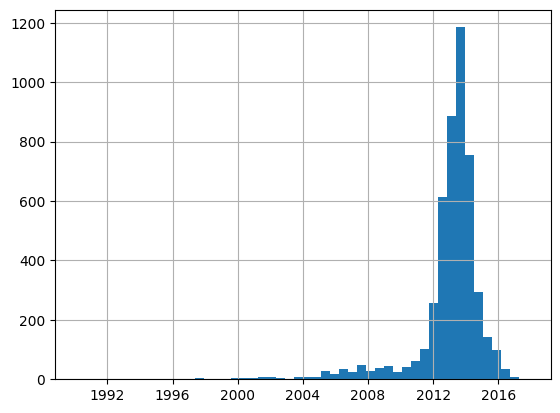

In [406]:
df_limpio['fecha_registro'].hist(bins=50)

In [404]:
df_limpio[df_limpio['fecha_registro'] < pd.Timestamp('1999-01-01')]

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
25,318,196092.0,85.0,1995-10-01,petrol,desconocido,convertible,True,False,False,False,False,False,False,1800.0,2018-05-01
2473,525,230578.0,85.0,1997-07-01,diesel,desconocido,sedan,False,False,False,False,False,True,False,200.0,2018-08-01
2574,525,229880.0,85.0,1997-07-01,diesel,black,sedan,False,False,False,False,False,True,False,200.0,2018-08-01
2611,525,230264.0,85.0,1997-07-01,diesel,black,sedan,False,False,False,False,False,True,False,200.0,2018-08-01
2771,316,146951.0,66.0,1990-03-01,petrol,white,sedan,False,False,False,False,False,False,False,1300.0,2018-04-01
2829,525,439060.0,105.0,1997-01-01,diesel,silver,estate,False,False,True,False,False,True,False,100.0,2018-03-01
3062,318,98097.0,85.0,1994-01-01,petrol,blue,sedan,True,False,False,False,False,True,True,400.0,2018-04-01
3380,525,245302.0,105.0,1997-01-01,diesel,green,estate,False,True,False,False,False,True,True,900.0,2018-06-01


In [357]:
df_inicial_test[df_inicial_test['fecha_registro'] < pd.Timestamp('1999-01-01')]

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
25,318,196092.0,85.0,1995-10-01,petrol,NaN,convertible,True,False,False,False,False,False,False,False,1800.0,2018-05-01
2473,525,230578.0,85.0,1997-07-01,diesel,NaN,sedan,False,NaN,False,False,False,False,True,NaN,200.0,2018-08-01
2574,525,229880.0,85.0,1997-07-01,diesel,black,sedan,False,NaN,False,False,False,NaN,True,False,200.0,2018-08-01
2611,525,230264.0,85.0,1997-07-01,diesel,black,sedan,False,False,False,False,False,False,True,False,200.0,2018-08-01
2771,316,146951.0,66.0,1990-03-01,petrol,white,sedan,False,False,False,NaN,False,False,False,False,1300.0,2018-04-01
3062,318,98097.0,85.0,1994-01-01,petrol,blue,sedan,True,False,False,False,False,False,True,True,400.0,2018-04-01
3380,525,245302.0,105.0,1997-01-01,diesel,green,NaN,False,True,False,NaN,False,False,True,True,900.0,2018-06-01


In [ ]:
df_limpio[df_limpio['fecha_registro'] > df_limpio['fecha_venta']]

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
42,330,142483.0,180.0,2013-05-01,diesel,blue,convertible,True,True,False,True,False,True,True,15800.0,2007-08-01
100,320,342768.0,135.0,2011-12-01,diesel,black,estate,False,True,False,True,False,True,True,8200.0,2010-04-01
180,320,181052.0,120.0,2013-06-01,diesel,black,estate,False,True,False,False,False,True,False,11500.0,2009-04-01
256,316,201102.0,85.0,2013-12-01,diesel,black,estate,True,True,False,False,False,True,False,8800.0,2008-06-01


In [308]:
# Quitamos fechas incoherentes
df_limpio_2 = df_limpio_2[df_limpio_2['fecha_registro'] <= df_limpio_2['fecha_venta']]

# Calculamos antigüedad
df_limpio_2["antigüedad"] = df_limpio_2["fecha_venta"] - df_limpio_2["fecha_registro"]
df_limpio_2['antigüedad'] = df_limpio_2['antigüedad'].dt.days / 365.25
df_limpio_2 = df_limpio_2.drop(columns=['fecha_venta','fecha_registro'])

In [309]:
df_limpio_2[df_limpio_2['km'] < 5000.0]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
471,318,3142.0,100.0,diesel,blue,estate,True,True,False,False,False,True,False,21400.0,1.418207
781,318,3478.0,100.0,diesel,blue,estate,True,True,False,False,False,True,False,21400.0,3.414100
2409,420 Gran Coupé,476.0,120.0,diesel,blue,hatchback,True,True,False,False,True,True,True,30300.0,2.250513
2938,640 Gran Coupé,-64.0,230.0,diesel,black,sedan,True,True,False,False,False,True,True,75000.0,2.332649
3687,116,2399.0,85.0,diesel,white,subcompact,False,False,False,False,False,True,False,17300.0,3.000684
3935,X5,706.0,155.0,diesel,black,suv,True,True,False,True,True,True,False,41600.0,0.588638
4146,X6 M,2970.0,423.0,petrol,red,suv,True,False,True,False,False,True,True,82400.0,1.998631
4372,X5,612.0,183.0,diesel,black,suv,True,True,False,False,False,True,True,49100.0,1.664613
4731,X5 M,4530.0,230.0,diesel,silver,suv,True,False,False,False,False,False,True,73100.0,2.083504


In [364]:
df_limpio_2[df_limpio_2['modelo'] == '640 Gran Coupé']['km'].median()

np.float64(103982.0)

In [413]:
df_limpio_2[df_limpio_2['km'] < 0.0]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
2938,640 Gran Coupé,-64.0,230.0,diesel,black,sedan,True,True,False,False,False,True,True,75000.0,2.332649


In [412]:
df_limpio_2[df_limpio_2['km'] < 0.0]['modelo'].iloc[0]

'640 Gran Coupé'

In [456]:
df_test = df_limpio_2.copy()
df_test.loc[df_test['km'] <= 0, 'km'] = df_test[df_test['modelo'] == df_test[df_test['km'] < 0.0]['modelo'].iloc[0]]['km'].median()
df_test.iloc[[2928]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
2938,640 Gran Coupé,103982.0,230.0,diesel,black,sedan,True,True,False,False,False,True,True,75000.0,2.332649


In [457]:
df_limpio_2[df_limpio_2['potencia'] < 50]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1796,i3,152328.0,25.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,20300.0,4.832307
1925,i3,152470.0,25.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,15500.0,4.747433
3765,X1,81770.0,0.0,diesel,white,suv,False,False,False,False,False,False,False,11700.0,3.414100


In [433]:
df_test.iloc[[1786, 1915, 3755]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1796,i3,152328.0,25.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,20300.0,4.832307
1925,i3,152470.0,25.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,15500.0,4.747433
3765,X1,81770.0,0.0,diesel,white,suv,False,False,False,False,False,False,False,11700.0,3.414100


In [458]:
df_limpio_2[(df_limpio_2['modelo'] == 'i3') & (df_limpio_2['precio'].between(15000.0, 25000.0))]['potencia'].value_counts()

potencia
25.0     2
75.0     2
125.0    1
Name: count, dtype: int64

In [460]:
df_test.loc[df_test['potencia'] < 50, 'potencia'] = None

In [461]:
df_test[df_test['potencia'].isnull()]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1796,i3,152328.0,NaN,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,20300.0,4.832307
1925,i3,152470.0,NaN,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,15500.0,4.747433
3765,X1,81770.0,NaN,diesel,white,suv,False,False,False,False,False,False,False,11700.0,3.414100


In [462]:
df_test[(df_test['modelo'] == 'i3') & (df_test['precio'].between(15000.0, 25000.0))]['potencia'].value_counts()

potencia
75.0     2
125.0    1
Name: count, dtype: int64

In [463]:
df_test[(df_test['modelo'] == 'X1') & (df_test['precio'].between(10000.0, 13000.0)) & (df_test['antigüedad'].between(2.2, 4.6))]['potencia'].value_counts(normalize=True)

potencia
85.0     0.500000
100.0    0.214286
105.0    0.142857
135.0    0.071429
120.0    0.071429
Name: proportion, dtype: float64

In [464]:
df_test = utils.imputar_por_similitud(
            df_test, target_col='potencia', numeric_cols={'antigüedad': 0.35, 'precio': 0.1},
            cat_bool_cols=['modelo'], umbral_dominancia=0.50, estrategia='moda',
            usar_percentiles=False
        )

df_test = utils.imputar_por_similitud(
            df_test, target_col='potencia', numeric_cols={'antigüedad': 0.35},
            cat_bool_cols=['modelo'], umbral_dominancia=0.50, estrategia='moda',
            usar_percentiles=False
        )

Procesando 3 nulos en 'potencia' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 2 de 3 (66.67%).
Procesando 1 nulos en 'potencia' | Estrategia: moda | Percentiles: False...
Terminado: Se imputaron 1 de 1 (100.0%).


In [465]:
df_test.iloc[[1786, 1915, 3755]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1796,i3,152328.0,75.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,20300.0,4.832307
1925,i3,152470.0,75.0,hybrid_petrol,black,hatchback,False,True,False,False,False,True,True,15500.0,4.747433
3765,X1,81770.0,85.0,diesel,white,suv,False,False,False,False,False,False,False,11700.0,3.414100


<Axes: >

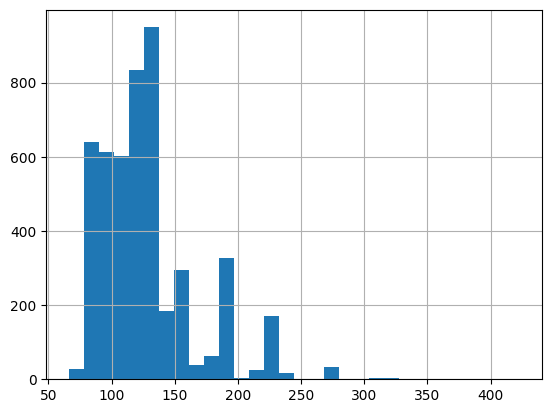

In [466]:
df_test['potencia'].hist(bins=30)

In [394]:
df_limpio_2[df_limpio_2['potencia'] > 300]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
1,M4,13929.0,317.0,petrol,grey,convertible,True,True,False,False,True,True,True,69700.0,3.252567
67,M3,29925.0,309.0,petrol,silver,coupe,True,True,False,True,True,True,True,47000.0,3.331964
72,M4,69410.0,317.0,petrol,white,convertible,True,True,False,False,True,True,True,53600.0,3.077344
73,M3,170550.0,309.0,petrol,grey,coupe,True,True,False,True,False,True,True,28000.0,7.000684
93,M3,99283.0,309.0,petrol,silver,coupe,False,False,False,True,False,True,True,28600.0,4.750171
139,M3,169970.0,309.0,petrol,grey,coupe,True,True,False,True,False,True,True,35700.0,7.419576
2944,M3,33670.0,317.0,petrol,blue,sedan,True,True,False,False,True,True,True,51200.0,4.084873
3092,M3,39250.0,317.0,petrol,black,sedan,True,True,False,False,True,True,True,52400.0,2.496920
3601,M5,150187.0,412.0,petrol,white,sedan,True,True,True,True,True,True,True,41600.0,5.251198
4146,X6 M,2970.0,423.0,petrol,red,suv,True,False,True,False,False,True,True,82400.0,1.998631


<Axes: >

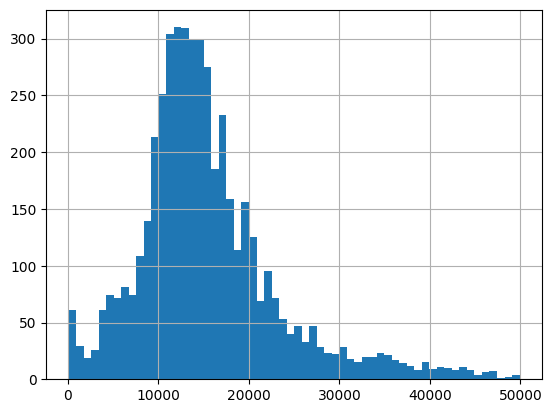

In [403]:
df_test[df_test['precio'] < 50000]['precio'].hist(bins=60)
# df_test['precio'].hist(bins=60)

<Axes: >

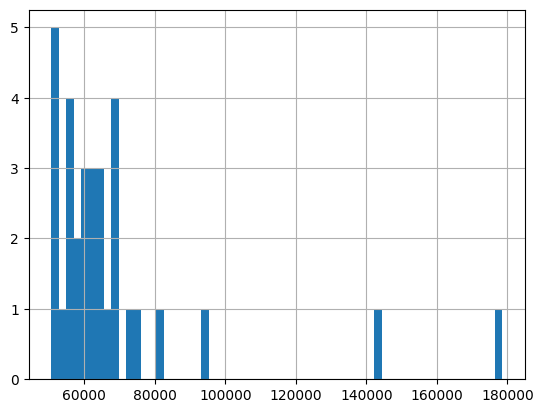

In [401]:
df_test[df_test['precio'] > 50000]['precio'].hist(bins=60)

In [475]:
df_test[df_test['modelo'].map(df_test['modelo'].value_counts()) < 2]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
55,225,78638.0,160.0,diesel,black,coupe,False,True,False,False,True,True,True,18300.0,4.251882
90,i8,12402.0,170.0,hybrid_petrol,grey,coupe,True,True,False,False,False,False,True,95200.0,3.331964
107,630,149943.0,190.0,petrol,black,coupe,True,True,True,True,True,True,True,10500.0,4.914442
142,635,173302.0,210.0,diesel,grey,coupe,True,True,True,True,False,True,True,19300.0,8.251882
1899,M135,94497.0,239.0,petrol,grey,hatchback,True,False,False,True,False,True,False,25700.0,3.756331
2925,ActiveHybrid 5,94374.0,225.0,hybrid_petrol,brown,sedan,True,True,False,True,True,True,True,21100.0,5.916496
3154,735,184189.0,200.0,petrol,grey,sedan,True,True,False,False,False,True,True,4500.0,5.166324
3601,M5,150187.0,412.0,petrol,white,sedan,True,True,True,True,True,True,True,41600.0,5.251198
4803,216,31079.0,85.0,diesel,black,van,False,True,False,False,False,False,False,4800.0,3.329227
4804,220 Active Tourer,153358.0,140.0,diesel,grey,van,False,False,False,False,False,True,True,11700.0,2.672142


In [494]:
df_test[(df_test['modelo'].str.endswith('Active Tourer'))]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
4799,218 Active Tourer,35888.0,100.0,diesel,blue,van,False,True,False,False,False,True,False,16200.0,2.833676
4804,220 Active Tourer,153358.0,140.0,diesel,grey,van,False,False,False,False,False,True,True,11700.0,2.672142
4805,218 Active Tourer,35382.0,110.0,diesel,desconocido,van,False,True,False,False,False,True,True,13100.0,2.672142
4807,218 Active Tourer,197276.0,112.0,diesel,white,van,True,True,False,False,False,True,True,13100.0,5.336071
4810,216 Active Tourer,193657.0,85.0,diesel,silver,van,False,False,False,False,False,True,False,8900.0,3.504449
4813,216 Active Tourer,117375.0,85.0,diesel,black,van,False,True,False,False,False,True,False,12300.0,2.833676
4820,Active Tourer,48380.0,100.0,diesel,black,van,True,False,False,False,False,True,False,19000.0,3.581109
4821,218 Active Tourer,91512.0,100.0,petrol,white,van,False,True,True,False,False,True,False,14300.0,2.915811
4822,218 Active Tourer,153159.0,110.0,diesel,black,van,False,True,False,False,False,False,False,13200.0,4.914442
4823,218 Active Tourer,150904.0,112.0,diesel,black,van,True,True,False,False,False,True,False,11800.0,4.914442


In [498]:
df_test[(df_test['modelo'].str.endswith('Active Tourer')) & (df_test['antigüedad'].between(2.5, 4.5)) & (df_test['potencia'] == 100.0)]#['modelo'].value_counts()

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
4799,218 Active Tourer,35888.0,100.0,diesel,blue,van,False,True,False,False,False,True,False,16200.0,2.833676
4820,Active Tourer,48380.0,100.0,diesel,black,van,True,False,False,False,False,True,False,19000.0,3.581109
4821,218 Active Tourer,91512.0,100.0,petrol,white,van,False,True,True,False,False,True,False,14300.0,2.915811
4827,218 Active Tourer,65689.0,100.0,diesel,grey,van,False,True,False,False,False,True,True,17300.0,3.000684
4831,218 Active Tourer,43278.0,100.0,diesel,black,van,False,True,False,False,False,True,True,17100.0,3.167693
4836,218 Active Tourer,81230.0,100.0,diesel,black,van,False,True,False,False,False,True,False,14200.0,3.000684
4839,218 Active Tourer,49832.0,100.0,diesel,grey,van,False,True,False,False,False,True,True,17500.0,3.167693


In [500]:
df_test.loc[[4820]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
4820,Active Tourer,48380.0,100.0,diesel,black,van,True,False,False,False,False,True,False,19000.0,3.581109


In [504]:
df_test.loc[df_test['modelo'] == ' Active Tourer', 'modelo'] = '218 Active Tourer'
df_test.loc[[4820]]

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,antigüedad
4820,218 Active Tourer,48380.0,100.0,diesel,black,van,True,False,False,False,False,True,False,19000.0,3.581109


<Axes: >

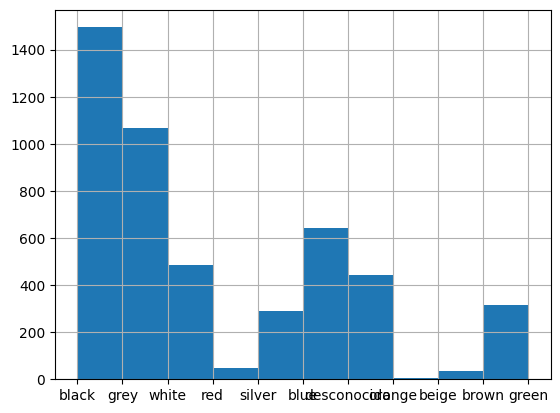

In [468]:
df_test['color'].hist()

<Axes: >

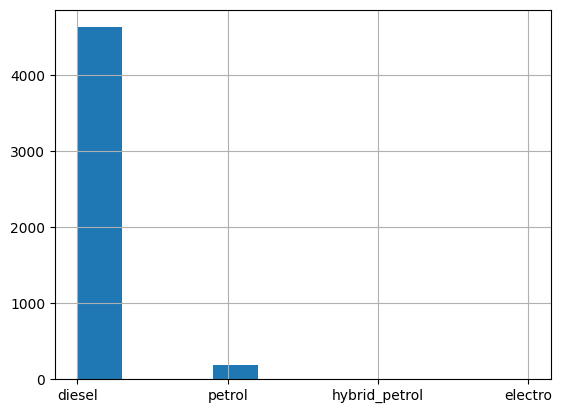

In [505]:
df_test['tipo_gasolina'].hist()

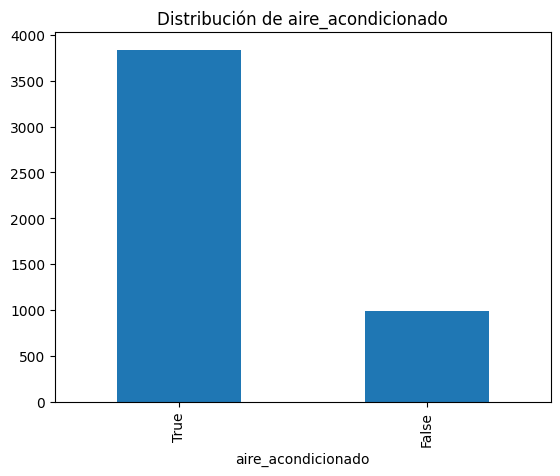

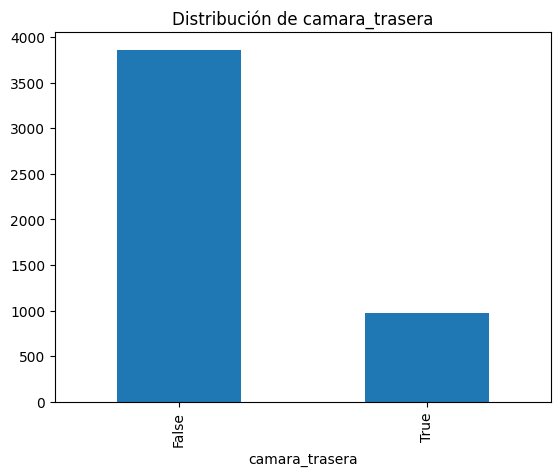

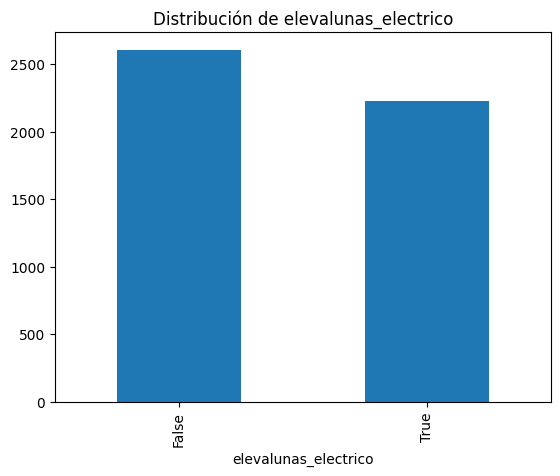

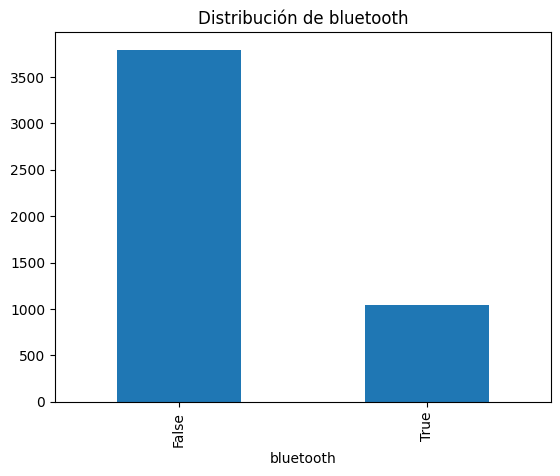

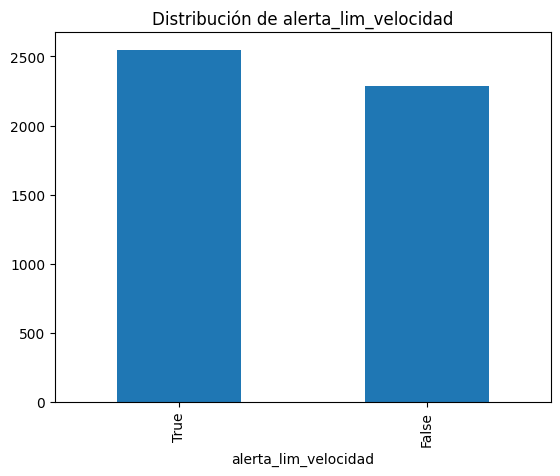

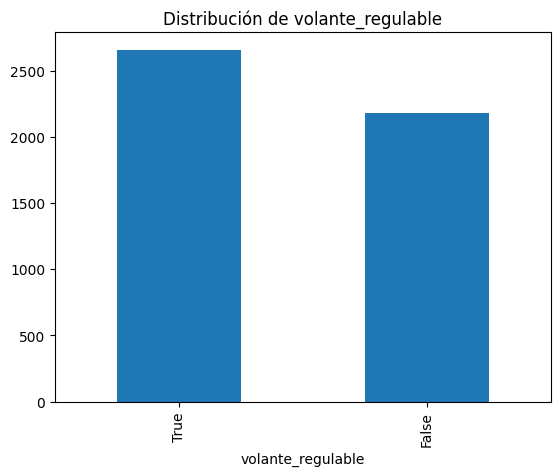

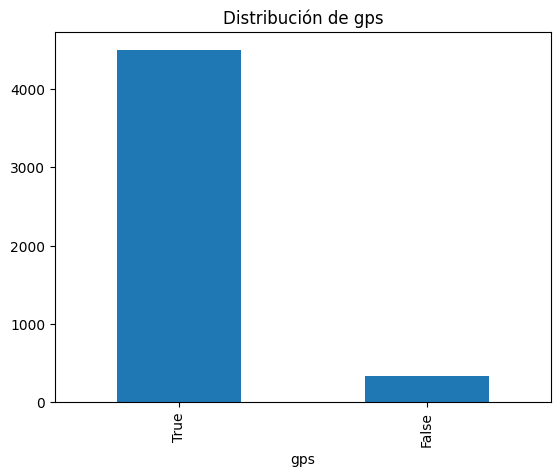

In [516]:
for col in target_equipamiento:
    plt.figure()  # Crea un lienzo nuevo en cada vuelta
    df_test[col].value_counts().plot(kind='bar', title=f'Distribución de {col}')
    plt.show()    # Fuerza a que se pinte ahora mismo

Tiene más probabilidad de tener gps que un elevalunas eléctrico

---

Correlaciones por tipo de dato

In [524]:
df_corr = df_test.copy()
for col in target_equipamiento:
    if col in df_corr.columns:
        # Convertimos 1.0 -> True, 0.0 -> False
        df_corr[col] = df_corr[col].astype(bool)

In [528]:
corr_bool = df_corr[target_equipamiento].corr(numeric_only = True)
corr_bool.style.background_gradient(cmap='cividis')

,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,alerta_lim_velocidad,volante_regulable,gps
aire_acondicionado,1.000000,0.135681,0.256572,0.105973,0.204307,0.288580,0.340098
camara_trasera,0.135681,1.000000,0.199092,0.139530,0.194541,0.254555,0.062058
elevalunas_electrico,0.256572,0.199092,1.000000,0.238844,0.333400,0.278037,0.203594
bluetooth,0.105973,0.139530,0.238844,1.000000,0.099767,0.132221,0.117629
alerta_lim_velocidad,0.204307,0.194541,0.333400,0.099767,1.000000,0.221299,-0.068254
volante_regulable,0.288580,0.254555,0.278037,0.132221,0.221299,1.000000,0.244163
gps,0.340098,0.062058,0.203594,0.117629,-0.068254,0.244163,1.000000


In [530]:
cols_numericas = ['precio', 'km', 'potencia', 'antigüedad']
corr_num = df_corr[cols_numericas].corr(numeric_only = True)
corr_num.style.background_gradient(cmap='cividis')

,precio,km,potencia,antigüedad
precio,1.000000,-0.407886,0.640631,-0.401691
km,-0.407886,1.000000,-0.050180,0.538452
potencia,0.640631,-0.050180,1.000000,-0.098864
antigüedad,-0.401691,0.538452,-0.098864,1.000000


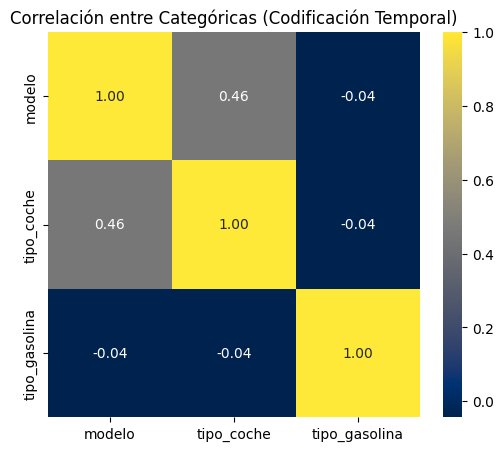

In [534]:
# 1. Creamos una copia para no dañar el dataset original
df_cat_numerica = df_corr[target_estructural].copy()

# 2. Convertimos texto a números (Factorize)
# Esto asigna 0, 1, 2... a cada categoría única
for col in target_estructural:
    df_cat_numerica[col] = pd.factorize(df_cat_numerica[col])[0]

# 3. Ahora sí podemos hacer la correlación (Usamos Spearman porque no son lineales)
corr_cat = df_cat_numerica.corr(method='spearman')

# 4. Visualización
plt.figure(figsize=(6, 5))
sns.heatmap(corr_cat, annot=True, cmap='cividis', fmt=".2f")
plt.title('Correlación entre Categóricas (Codificación Temporal)')
plt.show()

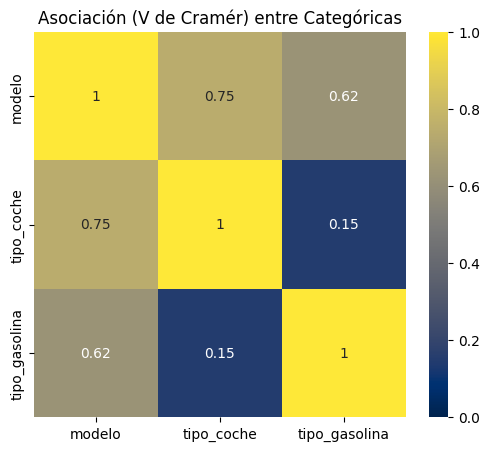

In [536]:
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Calcular la matriz
cols = target_estructural # ['modelo', 'tipo_coche', 'tipo_gasolina']
cramer_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df_test[col1], df_test[col2])

# Visualizar
plt.figure(figsize=(6, 5))
sns.heatmap(cramer_matrix, annot=True, cmap='cividis', vmin=0, vmax=1)
plt.title('Asociación (V de Cramér) entre Categóricas')
plt.show()

---

Correlación con target

<Figure size 1500x500 with 0 Axes>

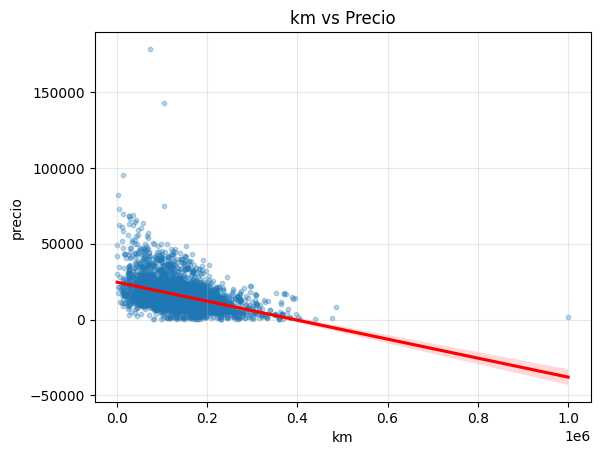

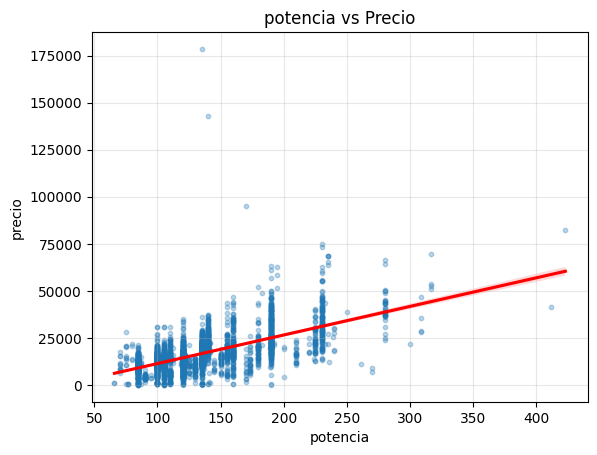

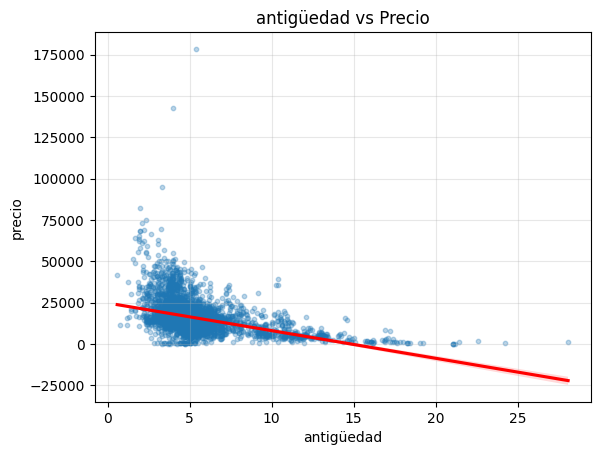

<Figure size 640x480 with 0 Axes>

In [541]:
df_analisis = df_test.copy() # O df_inicial_test_knn, el que estés usando

# Variables numéricas continuas
nums = ['km', 'potencia', 'antigüedad'] 

plt.figure(figsize=(15, 5))

for i, col in enumerate(nums):
    plt.figure()
    # Usamos regplot para ver la línea de tendencia automáticamente
    sns.regplot(x=col, y='precio', data=df_analisis, 
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    plt.title(f'{col} vs Precio')
    plt.grid(True, alpha=0.3)
    plt.show()

plt.tight_layout()
plt.show()

C:\Users\j\AppData\Local\Temp\ipykernel_13600\3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


<Figure size 1500x1200 with 0 Axes>

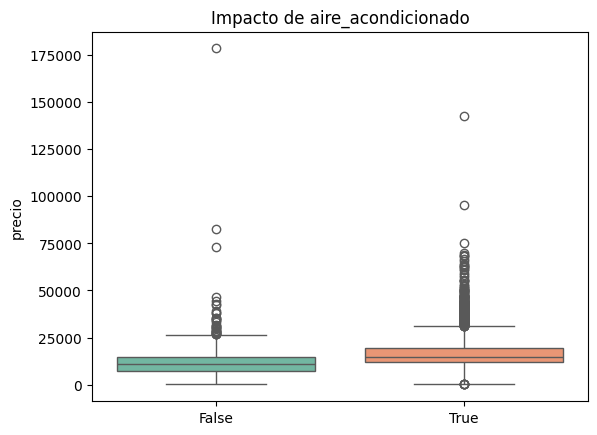

C:\Users\j\AppData\Local\Temp\ipykernel_13600\3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


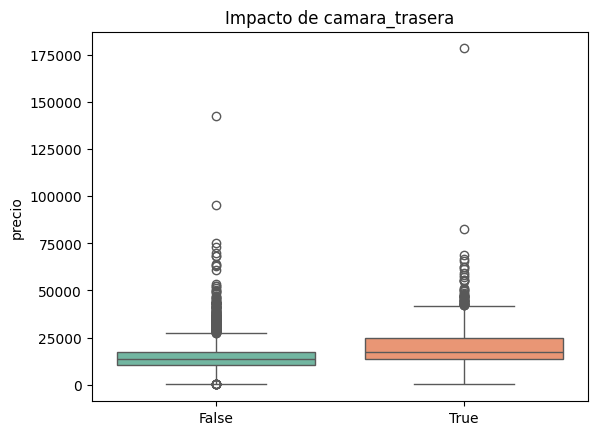

C:\Users\j\AppData\Local\Temp\ipykernel_13600\3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


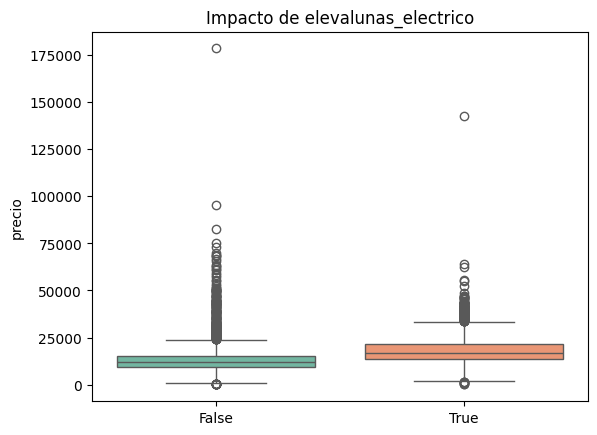

C:\Users\j\AppData\Local\Temp\ipykernel_13600\3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


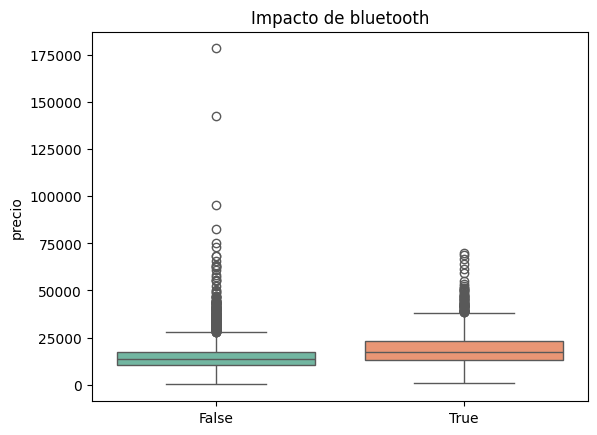

C:\Users\j\AppData\Local\Temp\ipykernel_13600\3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


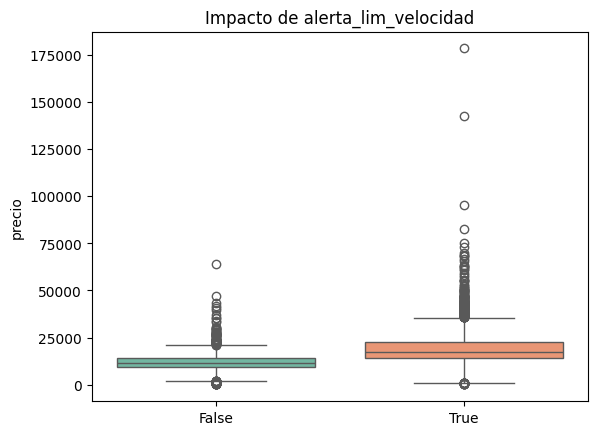

C:\Users\j\AppData\Local\Temp\ipykernel_13600\3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


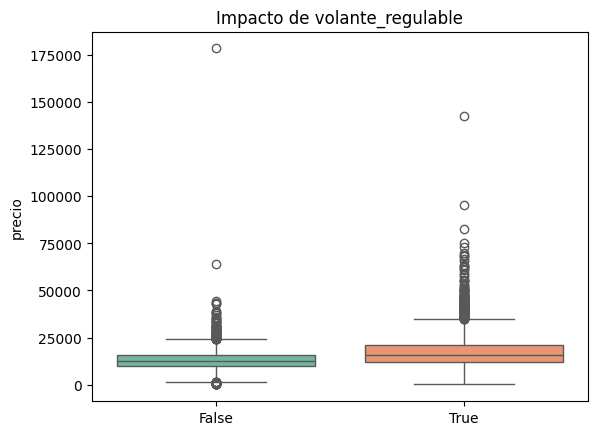

C:\Users\j\AppData\Local\Temp\ipykernel_13600\3989895093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')


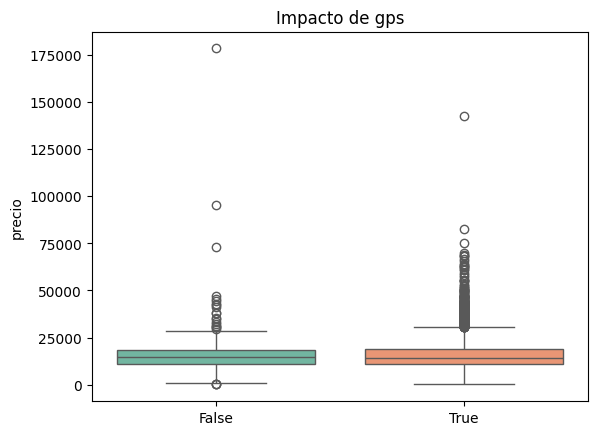

<Figure size 640x480 with 0 Axes>

In [542]:
# Lista de equipamiento
cols_equip = target_equipamiento # ['aire_acondicionado', 'gps', etc.]

# Configuración del grid para pintar muchos gráficos
n_cols = 3
n_rows = (len(cols_equip) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(cols_equip):
    plt.figure()
    # Boxplot: Compara la distribución de precios si TIENE o NO TIENE el extra
    sns.boxplot(x=col, y='precio', data=df_analisis, palette='Set2')
    plt.title(f'Impacto de {col}')
    plt.xlabel('') # Quitamos etiqueta x para limpiar
    plt.show()
    
plt.tight_layout()
plt.show()

C:\Users\j\AppData\Local\Temp\ipykernel_13600\3245514257.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y='modelo', x='precio', data=data_to_plot, order=order, palette='viridis')


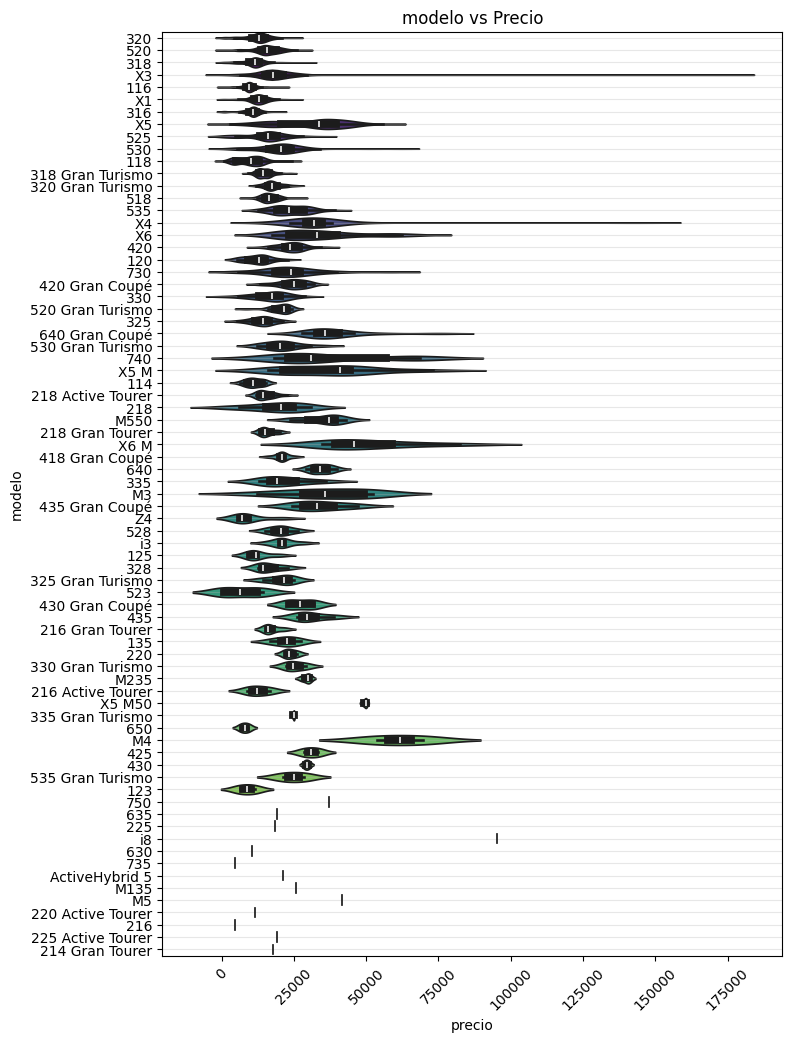

In [558]:
plt.figure(figsize=(8, 12))
top_n = df_analisis['modelo'].value_counts().index
data_to_plot = df_analisis[df_analisis['modelo'].isin(top_n)]
order = top_n
titulo = f'{'modelo'} vs Precio'
sns.violinplot(y='modelo', x='precio', data=data_to_plot, order=order, palette='viridis')
plt.title(titulo)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\j\AppData\Local\Temp\ipykernel_13600\1978857333.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=data_to_plot, order=order, palette='viridis')


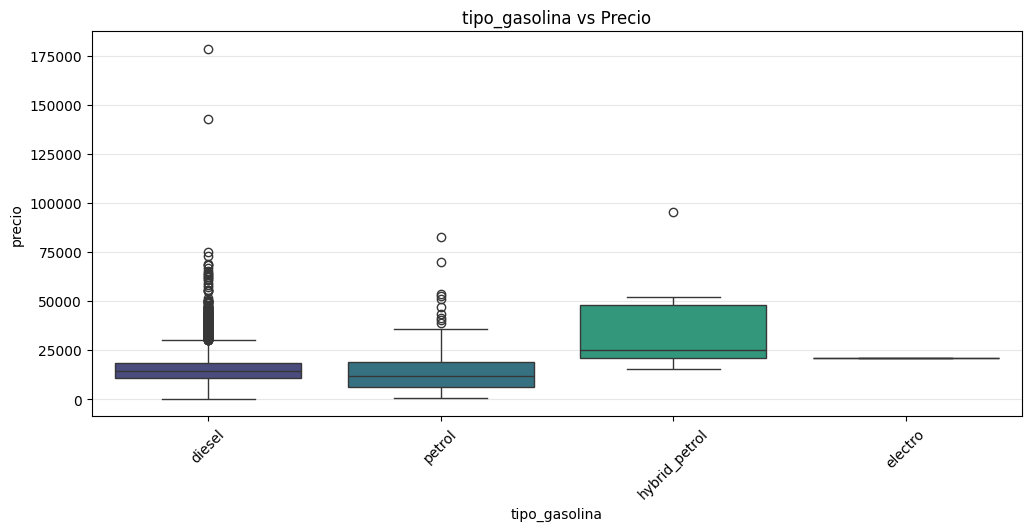

C:\Users\j\AppData\Local\Temp\ipykernel_13600\1978857333.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=data_to_plot, order=order, palette='viridis')


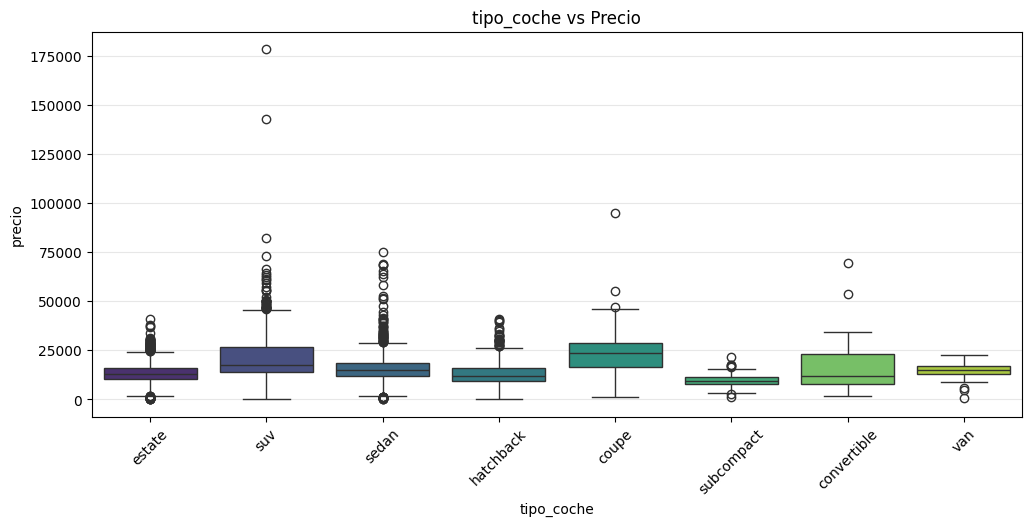

C:\Users\j\AppData\Local\Temp\ipykernel_13600\1978857333.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='precio', data=data_to_plot, order=order, palette='viridis')


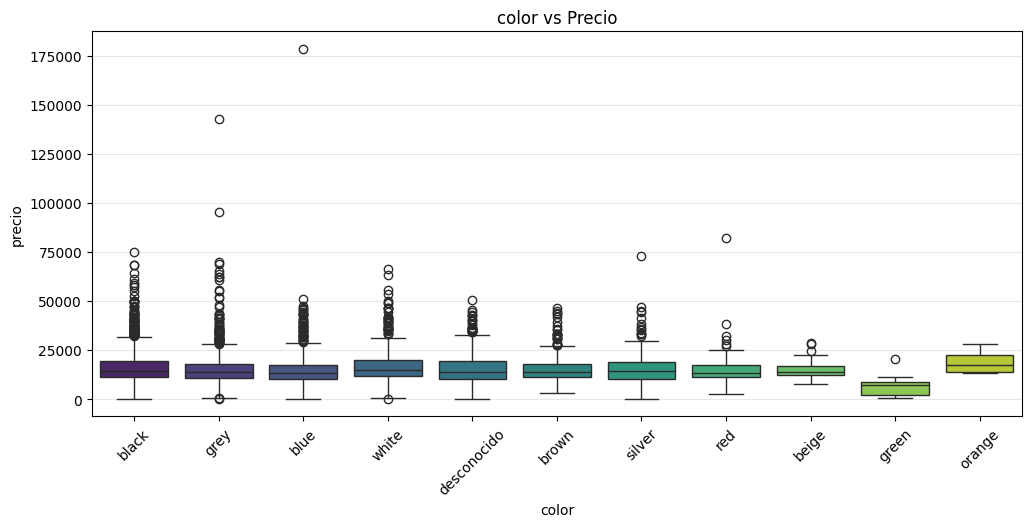

In [548]:
cols_cat = ['tipo_gasolina', 'tipo_coche', 'color']

for col in cols_cat:
    plt.figure(figsize=(12, 5))
    data_to_plot = df_analisis
    order = df_analisis[col].value_counts().index # Ordenar por frecuencia
    titulo = f'{col} vs Precio'
    sns.boxplot(x=col, y='precio', data=data_to_plot, order=order, palette='viridis')
    plt.title(titulo)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

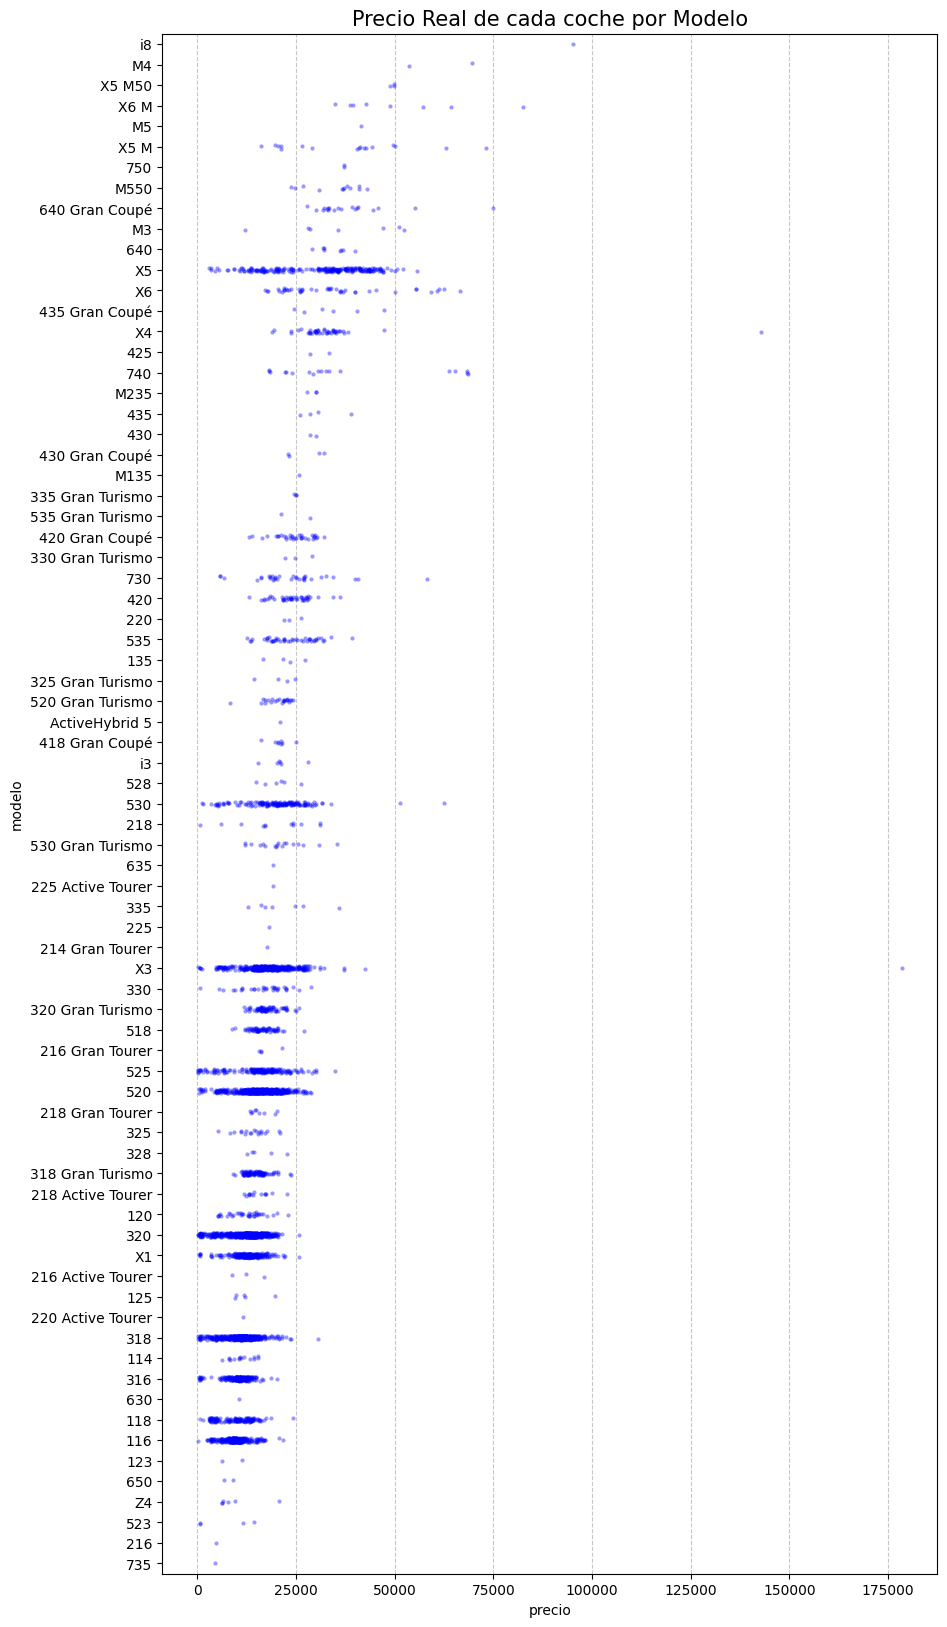

In [573]:
plt.figure(figsize=(10, 20))

# Usamos el mismo orden de precio
orden_precio = df_analisis.groupby('modelo')['precio'].median().sort_values(ascending=False).index

sns.stripplot(x='precio', y='modelo', data=df_analisis, 
              order=orden_precio, color='blue', 
              size=3, alpha=0.4, jitter=True)

plt.title('Precio Real de cada coche por Modelo', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

---

OHE para color, tipo_gasolina, tipo_coche

CatBoost para modelo

---

In [310]:
!pip install category_encoders
# import category_encoders as ce

In [311]:
import sys
import os

# Esta es la ruta que apareció en tu error como "Requirement satisfied"
path_libreria = r"c:\users\j\desktop\joaquín\clase\master\vsc\penv\lib\site-packages"

if path_libreria not in sys.path:
    sys.path.append(path_libreria)

# Ahora intenta importar
import category_encoders as ce

In [312]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor # Usamos un modelo robusto y genérico
from category_encoders import CatBoostEncoder

def comparar_encodings(df, col_cat, col_target, umbral_frecuencia=0.9):
    """
    Compara 3 estrategias de encoding:
    1. Vanilla One-Hot (Todas las categorías).
    2. Top X% One-Hot (Agrupa categorías raras como 'Otros').
    3. CatBoost Encoding (Encoding basado en el target).
    
    Args:
        df: Dataframe original.
        col_cat: Nombre de la columna categórica a codificar (ej: 'modelos').
        col_target: Nombre de la columna objetivo (target) para entrenar (ej: 'precio').
        umbral_frecuencia: Porcentaje (0.0 a 1.0) para el corte de frecuencia (def: 0.9).
    """
    
    # 1. Preparación de datos (Evitamos modificar el df original fuera de la función)
    df_temp = df.copy()
    
    # Aseguramos que no haya nulos para el ejemplo
    df_temp = df_temp.dropna(subset=[col_cat, col_target])
    
    # Separamos X (solo la columna a probar) e y
    X = df_temp[[col_cat]]
    y = df_temp[col_target]
    
    results = {}
    
    # ---------------------------------------------------------
    # MÉTODO 1: Vanilla One-Hot Encoding
    # ---------------------------------------------------------
    print(f"--- Procesando Método 1: Vanilla One-Hot ---")
    X_vanilla = pd.get_dummies(X[col_cat], prefix='OHE', drop_first=True)
    
    # Evaluamos
    score_vanilla = evaluar_modelo(X_vanilla, y)
    results['Vanilla OHE'] = {'R2_Score': score_vanilla, 'Num_Columnas': X_vanilla.shape[1]}
    
    # ---------------------------------------------------------
    # MÉTODO 2: One-Hot Top X% (Agrupando 'Otros')
    # ---------------------------------------------------------
    print(f"--- Procesando Método 2: Top {umbral_frecuencia*100}% One-Hot ---")
    
    # Calculamos frecuencias
    counts = df_temp[col_cat].value_counts(normalize=True)
    cumulative = counts.cumsum()
    
    # Filtramos las categorías que entran en el % acumulado
    top_categories = cumulative[cumulative < umbral_frecuencia].index
    
    # Aplicamos la transformación "Otros"
    X_top = X.copy()
    X_top['new_cat'] = X_top[col_cat].apply(lambda x: x if x in top_categories else 'Otros')
    
    # One Hot sobre la nueva columna reducida
    X_top_ohe = pd.get_dummies(X_top['new_cat'], prefix='Top_OHE', drop_first=True)
    
    # Evaluamos
    score_top = evaluar_modelo(X_top_ohe, y)
    results[f'Top {int(umbral_frecuencia*100)}% OHE'] = {'R2_Score': score_top, 'Num_Columnas': X_top_ohe.shape[1]}

    # ---------------------------------------------------------
    # MÉTODO 3: CatBoost Encoding
    # ---------------------------------------------------------
    print(f"--- Procesando Método 3: CatBoost Encoding ---")
    
    # El encoder de CatBoost necesita ver el target
    cbe = CatBoostEncoder()
    # Importante: CatBoostEncoder suele requerir fit_transform con y
    X_cbe = cbe.fit_transform(X[col_cat], y)
    
    # Evaluamos
    score_cbe = evaluar_modelo(X_cbe, y)
    results['CatBoost Enc'] = {'R2_Score': score_cbe, 'Num_Columnas': X_cbe.shape[1]}
    
    # ---------------------------------------------------------
    # Visualización de Resultados
    # ---------------------------------------------------------
    df_res = pd.DataFrame(results).T
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Gráfico de Barras para el Score (Rendimiento)
    color = 'tab:blue'
    ax1.set_xlabel('Método de Encoding')
    ax1.set_ylabel('R2 Score (Mayor es mejor)', color=color)
    bars = ax1.bar(df_res.index, df_res['R2_Score'], color=color, alpha=0.6, label='Precision Modelo')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(0, 1) # Asumiendo R2, ajusta si usas otra métrica

    # Eje secundario para el número de columnas (Dimensionalidad)
    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Número de Columnas Generadas', color=color)
    line = ax2.plot(df_res.index, df_res['Num_Columnas'], color=color, marker='o', linewidth=2, linestyle='--', label='Dimensionalidad')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Comparativa de Encodings: Rendimiento vs Dimensionalidad (Umbral: {umbral_frecuencia})')
    fig.tight_layout()
    plt.show()
    
    return df_res

def evaluar_modelo(X, y):
    """Función auxiliar para entrenar y evaluar rápidamente con Validación Cruzada"""
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    # Usamos cross_val_score para ser más honestos con el resultado (R2 score negativo = mal modelo)
    scores = cross_val_score(model, X, y, cv=3, scoring='r2')
    return scores.mean()

--- Procesando Método 1: Vanilla One-Hot ---
--- Procesando Método 2: Top 80.0% One-Hot ---
--- Procesando Método 3: CatBoost Encoding ---


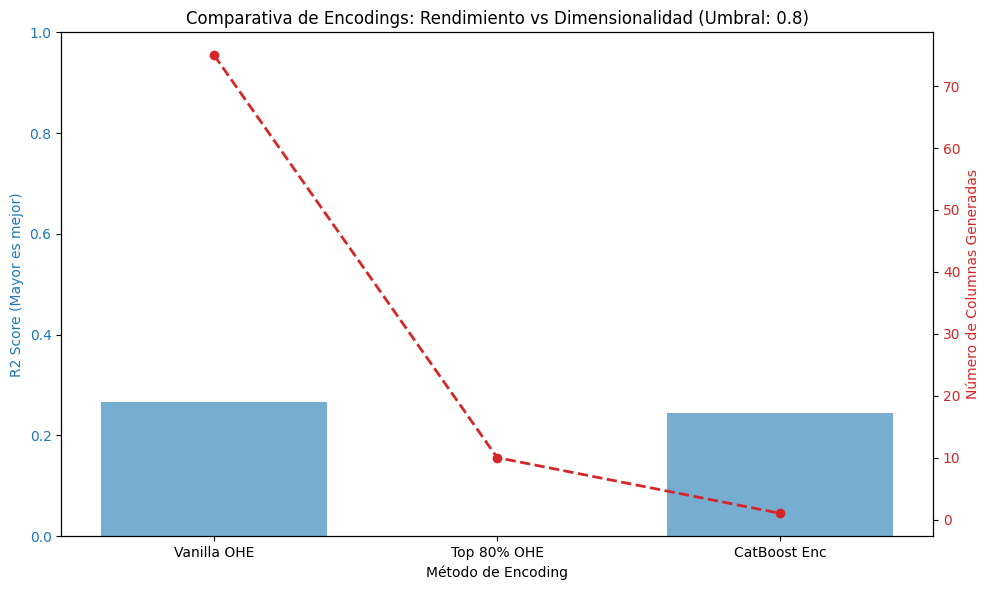

              R2_Score  Num_Columnas
Vanilla OHE   0.267200          75.0
Top 80% OHE  -0.007937          10.0
CatBoost Enc  0.245517           1.0


In [313]:
df_resultados = comparar_encodings(df_inicial_test, 'modelo', 'precio', umbral_frecuencia=0.80)
print(df_resultados)

--- Procesando Método 1: Vanilla One-Hot ---
--- Procesando Método 2: Top 90.0% One-Hot ---
--- Procesando Método 3: CatBoost Encoding ---


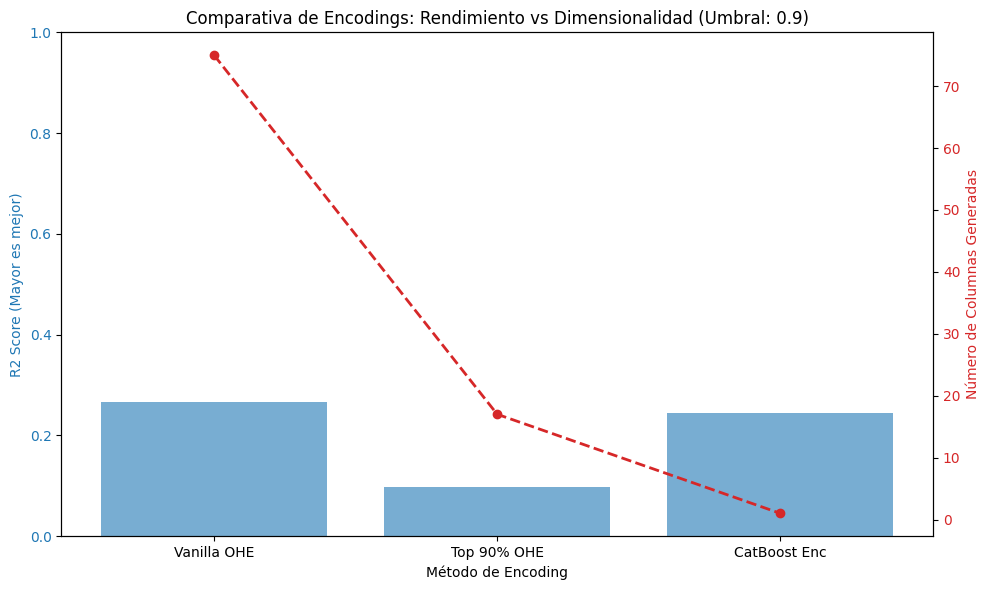

              R2_Score  Num_Columnas
Vanilla OHE   0.267200          75.0
Top 90% OHE   0.098231          17.0
CatBoost Enc  0.245517           1.0


In [314]:
df_resultados = comparar_encodings(df_inicial_test, 'modelo', 'precio', umbral_frecuencia=0.90)
print(df_resultados)

In [315]:
def comparar_encodings_v2(df, col_cat, col_target, umbral_frecuencia=0.9):
    """
    Compara 3 estrategias de encoding:
    1. Vanilla One-Hot (Todas las categorías).
    2. Top X% One-Hot (Agrupa categorías raras como 'Otros').
    3. CatBoost Encoding (Encoding basado en el target).
    
    Args:
        df: Dataframe original.
        col_cat: Nombre de la columna categórica a codificar (ej: 'modelos').
        col_target: Nombre de la columna objetivo (target) para entrenar (ej: 'precio').
        umbral_frecuencia: Porcentaje (0.0 a 1.0) para el corte de frecuencia (def: 0.9).
    """
    
    # 1. Preparación de datos (Evitamos modificar el df original fuera de la función)
    df_temp = df.copy()
    
    # Aseguramos que no haya nulos para el ejemplo
    df_temp = df_temp.dropna(subset=[col_cat, col_target])
    
    # Separamos X (solo la columna a probar) e y
    X = df_temp[[col_cat]]
    y = df_temp[col_target]
    
    results = {}
    
    # ---------------------------------------------------------
    # MÉTODO 1: Vanilla One-Hot Encoding
    # ---------------------------------------------------------
    print(f"--- Procesando Método 1: Vanilla One-Hot ---")
    X_vanilla = pd.get_dummies(X[col_cat], prefix='OHE', drop_first=True)
    
    # Evaluamos
    score_vanilla = evaluar_modelo(X_vanilla, y)
    results['Vanilla OHE'] = {'R2_Score': score_vanilla, 'Num_Columnas': X_vanilla.shape[1]}
    
    # ---------------------------------------------------------
    # MÉTODO 2: One-Hot Top X% (Lógica Mejorada)
    # ---------------------------------------------------------
    print(f"--- Procesando Método 2: Top {umbral_frecuencia*100}% One-Hot ---")
    
    counts = df_temp[col_cat].value_counts(normalize=True)
    cumulative = counts.cumsum()
    
    top_categories = cumulative[cumulative <= (umbral_frecuencia + 0.05)].index 
    
    # Si la lista queda vacía (porque el primero ya supera el umbral), cogemos el top 1 al menos
    if len(top_categories) == 0:
        top_categories = counts.index[:1]

    print(f"   -> Categorías mantenidas: {len(top_categories)} | Categorías en 'Otros': {len(counts) - len(top_categories)}")

    X_top = X.copy()
    X_top['new_cat'] = X_top[col_cat].apply(lambda x: x if x in top_categories else 'Otros')
    
    X_top_ohe = pd.get_dummies(X_top['new_cat'], prefix='Top_OHE', drop_first=True)
    
    score_top = evaluar_modelo(X_top_ohe, y)
    results[f'Top {int(umbral_frecuencia*100)}% OHE'] = {'R2_Score': score_top, 'Num_Columnas': X_top_ohe.shape[1]}
    # ---------------------------------------------------------
    # MÉTODO 3: CatBoost Encoding
    # ---------------------------------------------------------
    print(f"--- Procesando Método 3: CatBoost Encoding ---")
    
    # El encoder de CatBoost necesita ver el target
    cbe = CatBoostEncoder()
    # Importante: CatBoostEncoder suele requerir fit_transform con y
    X_cbe = cbe.fit_transform(X[col_cat], y)
    
    # Evaluamos
    score_cbe = evaluar_modelo(X_cbe, y)
    results['CatBoost Enc'] = {'R2_Score': score_cbe, 'Num_Columnas': X_cbe.shape[1]}
    
    # ---------------------------------------------------------
    # Visualización de Resultados
    # ---------------------------------------------------------
    df_res = pd.DataFrame(results).T
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Gráfico de Barras para el Score (Rendimiento)
    color = 'tab:blue'
    ax1.set_xlabel('Método de Encoding')
    ax1.set_ylabel('R2 Score (Mayor es mejor)', color=color)
    bars = ax1.bar(df_res.index, df_res['R2_Score'], color=color, alpha=0.6, label='Precision Modelo')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(0, 1) # Asumiendo R2, ajusta si usas otra métrica

    # Eje secundario para el número de columnas (Dimensionalidad)
    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Número de Columnas Generadas', color=color)
    line = ax2.plot(df_res.index, df_res['Num_Columnas'], color=color, marker='o', linewidth=2, linestyle='--', label='Dimensionalidad')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Comparativa de Encodings: Rendimiento vs Dimensionalidad (Umbral: {umbral_frecuencia})')
    fig.tight_layout()
    plt.show()
    
    return df_res



--- Procesando Método 1: Vanilla One-Hot ---
--- Procesando Método 2: Top 80.0% One-Hot ---
   -> Categorías mantenidas: 12 | Categorías en 'Otros': 64
--- Procesando Método 3: CatBoost Encoding ---


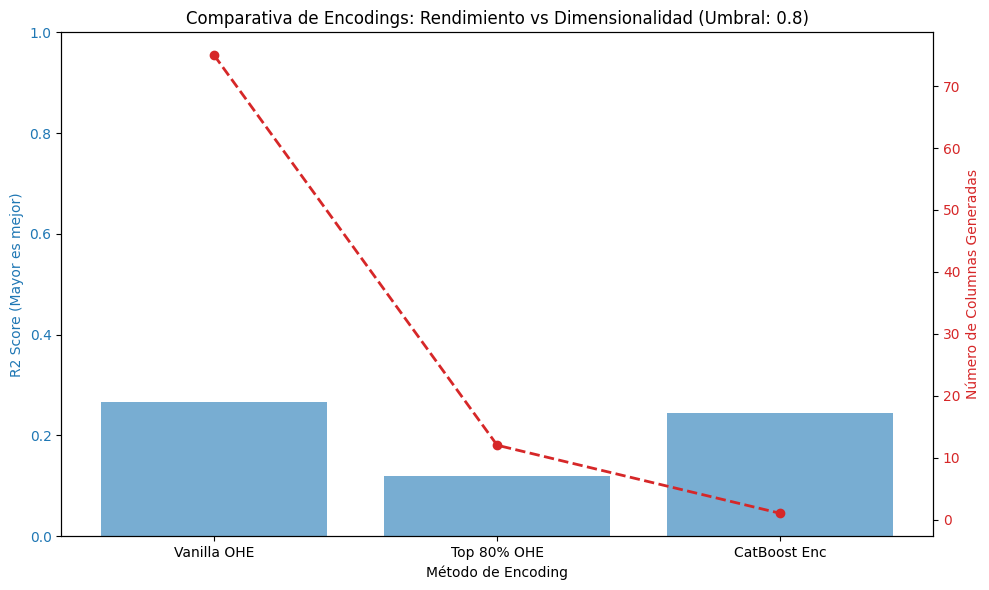

              R2_Score  Num_Columnas
Vanilla OHE   0.267200          75.0
Top 80% OHE   0.118682          12.0
CatBoost Enc  0.245517           1.0
--- Procesando Método 1: Vanilla One-Hot ---
--- Procesando Método 2: Top 90.0% One-Hot ---
   -> Categorías mantenidas: 25 | Categorías en 'Otros': 51
--- Procesando Método 3: CatBoost Encoding ---


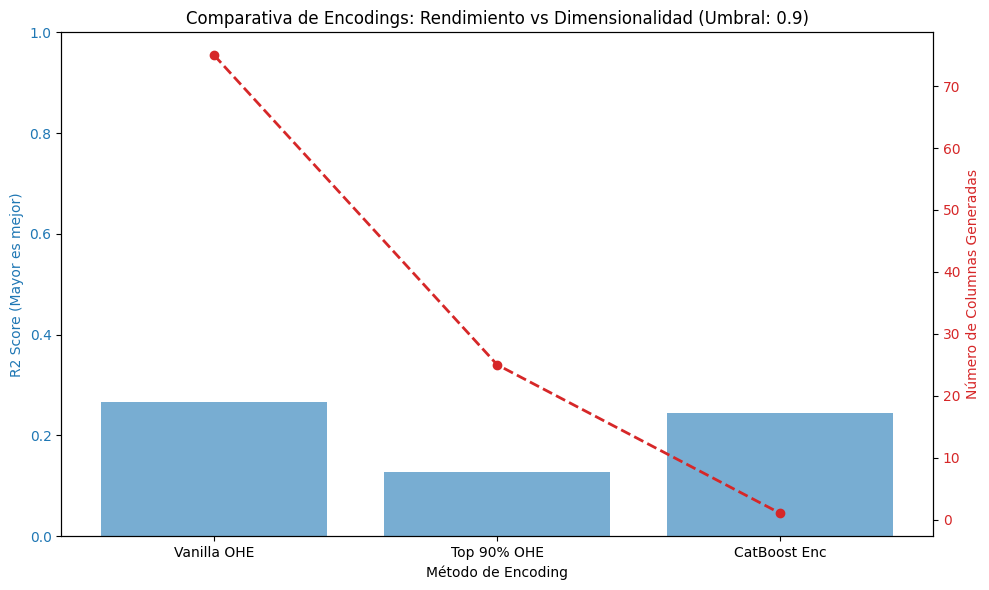

              R2_Score  Num_Columnas
Vanilla OHE   0.267200          75.0
Top 90% OHE   0.127778          25.0
CatBoost Enc  0.245517           1.0


In [316]:
df_resultados = comparar_encodings_v2(df_inicial_test, 'modelo', 'precio', umbral_frecuencia=0.80)
print(df_resultados)
df_resultados = comparar_encodings_v2(df_inicial_test, 'modelo', 'precio', umbral_frecuencia=0.90)
print(df_resultados)

--- Procesando Método 1: Vanilla One-Hot + 2 vars extra ---
--- Procesando Método 2: Top 90.0% + 2 vars extra ---
--- Procesando Método 3: CatBoost Encoding + 2 vars extra ---


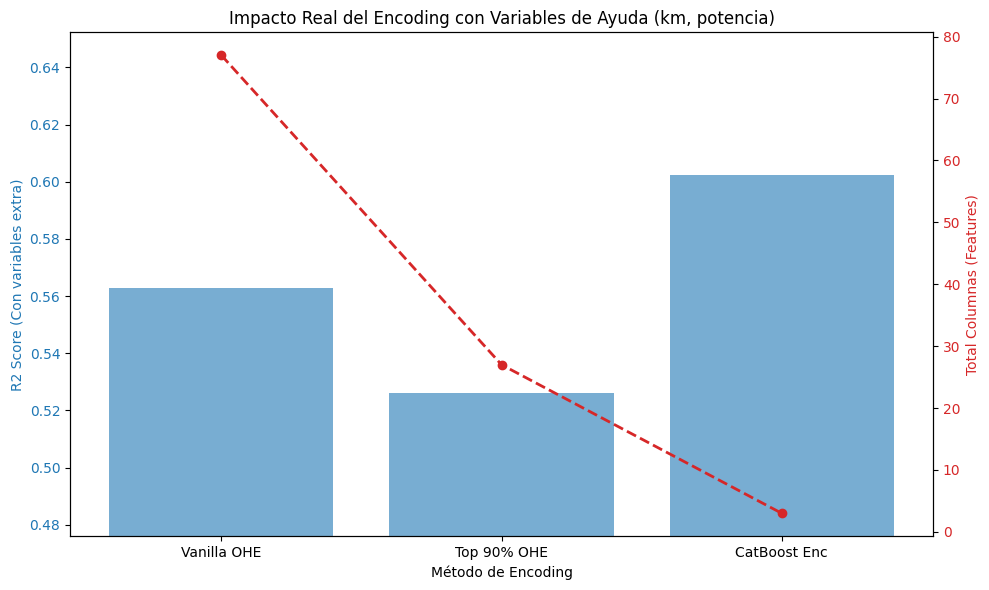

              R2_Score  Num_Columnas
Vanilla OHE   0.562717          77.0
Top 90% OHE   0.526029          27.0
CatBoost Enc  0.602245           3.0


In [317]:
def comparar_encodings_completo(df, col_cat, col_target, cols_extra=[], umbral_frecuencia=0.9):
    """
    Compara encodings incluyendo variables numéricas adicionales para ver el impacto real.
    Args:
        cols_extra: Lista de nombres de columnas numéricas (ej: ['km', 'ano', 'cv'])
    """
    
    # 1. Preparación
    # Seleccionamos todas las columnas necesarias
    cols_to_use = [col_cat, col_target] + cols_extra
    df_temp = df[cols_to_use].copy()
    
    # Eliminamos nulos en cualquiera de las columnas seleccionadas
    df_temp = df_temp.dropna()
    
    # Separamos Target
    y = df_temp[col_target]
    
    # Separamos Bloque Categórico y Bloque Numérico (Extra)
    X_cat = df_temp[[col_cat]]
    X_num = df_temp[cols_extra] # Esto es un DataFrame con las numéricas
    
    results = {}
    
    # ---------------------------------------------------------
    # MÉTODO 1: Vanilla One-Hot + Numéricas
    # ---------------------------------------------------------
    print(f"--- Procesando Método 1: Vanilla One-Hot + {len(cols_extra)} vars extra ---")
    # Codificamos solo la categórica
    X_cat_vanilla = pd.get_dummies(X_cat[col_cat], prefix='OHE', drop_first=True)
    # Concatenamos con las numéricas (Index align es automático)
    X_final_vanilla = pd.concat([X_num, X_cat_vanilla], axis=1)
    
    score_vanilla = evaluar_modelo(X_final_vanilla, y)
    results['Vanilla OHE'] = {'R2_Score': score_vanilla, 'Num_Columnas': X_final_vanilla.shape[1]}
    
    # ---------------------------------------------------------
    # MÉTODO 2: Top X% + Numéricas (Lógica Inclusiva)
    # ---------------------------------------------------------
    print(f"--- Procesando Método 2: Top {umbral_frecuencia*100}% + {len(cols_extra)} vars extra ---")
    
    counts = df_temp[col_cat].value_counts(normalize=True)
    cumulative = counts.cumsum()
    
    # Lógica inclusiva (Soft Cut)
    top_categories = cumulative[cumulative <= (umbral_frecuencia + 0.05)].index 
    if len(top_categories) == 0: top_categories = counts.index[:1]

    X_cat_top = X_cat.copy()
    X_cat_top['new_cat'] = X_cat_top[col_cat].apply(lambda x: x if x in top_categories else 'Otros')
    
    X_cat_top_ohe = pd.get_dummies(X_cat_top['new_cat'], prefix='Top_OHE', drop_first=True)
    
    # Concatenamos
    X_final_top = pd.concat([X_num, X_cat_top_ohe], axis=1)
    
    score_top = evaluar_modelo(X_final_top, y)
    results[f'Top {int(umbral_frecuencia*100)}% OHE'] = {'R2_Score': score_top, 'Num_Columnas': X_final_top.shape[1]}

    # ---------------------------------------------------------
    # MÉTODO 3: CatBoost Encoding + Numéricas
    # ---------------------------------------------------------
    print(f"--- Procesando Método 3: CatBoost Encoding + {len(cols_extra)} vars extra ---")
    
    cbe = CatBoostEncoder()
    # Transformamos SOLO la columna categórica
    X_cat_cbe = cbe.fit_transform(X_cat[col_cat], y)
    
    # Concatenamos con las numéricas
    X_final_cbe = pd.concat([X_num, X_cat_cbe], axis=1)
    
    score_cbe = evaluar_modelo(X_final_cbe, y)
    results['CatBoost Enc'] = {'R2_Score': score_cbe, 'Num_Columnas': X_final_cbe.shape[1]}
    
    # ---------------------------------------------------------
    # Visualización
    # ---------------------------------------------------------
    df_res = pd.DataFrame(results).T
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    color = 'tab:blue'
    ax1.set_xlabel('Método de Encoding')
    ax1.set_ylabel('R2 Score (Con variables extra)', color=color)
    bars = ax1.bar(df_res.index, df_res['R2_Score'], color=color, alpha=0.6)
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Ajustamos escala dinámica para ver diferencias pequeñas si el R2 es alto
    min_score = df_res['R2_Score'].min()
    max_score = df_res['R2_Score'].max()
    ax1.set_ylim(min_score - 0.05, max_score + 0.05)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Total Columnas (Features)', color=color)
    line = ax2.plot(df_res.index, df_res['Num_Columnas'], color=color, marker='o', linewidth=2, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Impacto Real del Encoding con Variables de Ayuda ({", ".join(cols_extra)})')
    fig.tight_layout()
    plt.show()
    
    return df_res

# --- EJEMPLO DE USO ---
# Define aquí tus columnas numéricas reales
columnas_numericas = ['km', 'potencia'] # <--- CAMBIA ESTO si tus columnas se llaman diferente

# Ejecutamos la comparación "Realista"
df_res_completo = comparar_encodings_completo(
    df_inicial_test, 
    'modelo', 
    'precio', 
    cols_extra=columnas_numericas, # Pasamos las columnas extra
    umbral_frecuencia=0.90
)

print(df_res_completo)

--- Procesando Método 1: Vanilla One-Hot + 2 vars extra ---
--- Procesando Método 2: Top 90.0% + 2 vars extra ---
--- Procesando Método 3: CatBoost Encoding + 2 vars extra ---


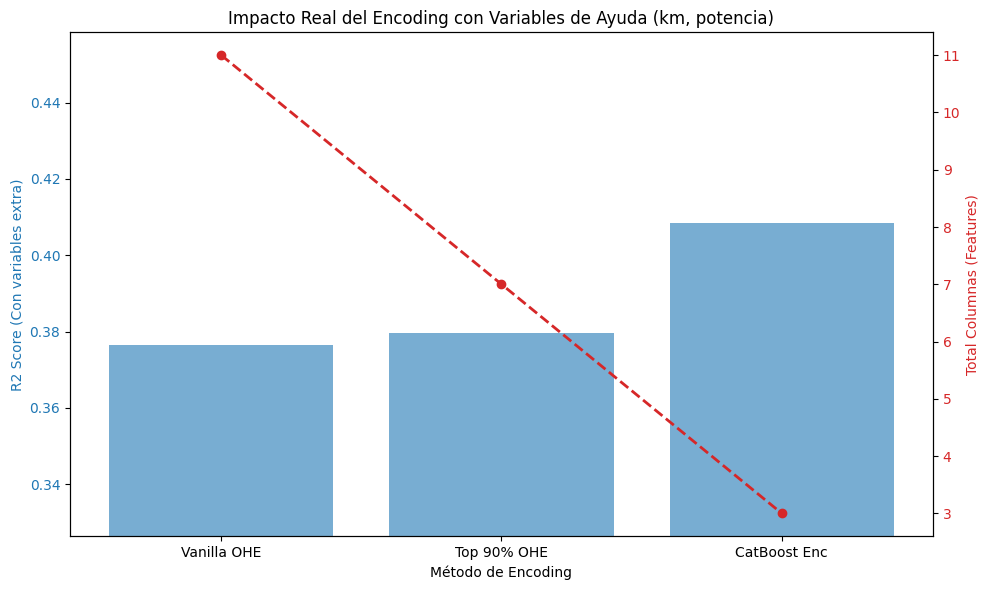

              R2_Score  Num_Columnas
Vanilla OHE   0.376373          11.0
Top 90% OHE   0.379652           7.0
CatBoost Enc  0.408406           3.0


In [318]:
df_res_completo = comparar_encodings_completo(
    df_inicial_test, 
    'color', 
    'precio', 
    cols_extra=columnas_numericas, # Pasamos las columnas extra
    umbral_frecuencia=0.90
)

print(df_res_completo)

In [319]:
frecuencias = df_inicial_test['modelo'].value_counts(normalize=True, dropna=False)
acumulado = frecuencias.cumsum()
display(acumulado.head(20)*100)

display(df_inicial_test['modelo'].value_counts(dropna=False).head(20))

modelo
320                 15.527566
520                 28.597976
318                 40.326244
X3                  49.370225
116                 56.762337
X1                  62.419988
316                 67.272352
X5                  72.042123
525                 75.841421
530                 79.083213
118                 82.035928
318 Gran Turismo    84.038819
320 Gran Turismo    85.546149
518                 86.908941
535                 87.858765
X4                  88.808590
420                 89.717117
X6                  90.625645
120                 91.368986
420 Gran Coupé      92.050382
Name: proportion, dtype: float64

modelo
320                 752
520                 633
318                 568
X3                  438
116                 358
X1                  274
316                 235
X5                  231
525                 184
530                 157
118                 143
318 Gran Turismo     97
320 Gran Turismo     73
518                  66
535                  46
X4                   46
420                  44
X6                   44
120                  36
420 Gran Coupé       33
Name: count, dtype: int64

In [320]:
display(df_inicial_test[df_inicial_test['modelo'].isnull()])

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
173,BMW,NaN,146338.0,105.0,NaT,diesel,black,NaN,False,True,False,NaN,False,NaN,True,NaN,13300.0,2018-08-01
4766,BMW,NaN,115566.0,105.0,2014-01-01,diesel,silver,suv,False,True,False,NaN,True,False,True,False,14900.0,2018-09-01
4802,BMW,NaN,118640.0,110.0,NaT,diesel,white,NaN,False,False,False,NaN,False,False,False,False,800.0,2018-03-01


In [321]:
df_inicial_test[(df_inicial_test['potencia'].between(100.0, 110.0)) & (df_inicial_test['tipo_coche'] == 'suv') & (df_inicial_test['precio'].between(13000.0, 15000.0)) & (df_inicial_test['km'].between(100000.0, 150000.0))]['modelo'].value_counts()

modelo
X1    9
X3    5
Name: count, dtype: int64

In [322]:
df_inicial_test[(df_inicial_test['potencia'].between(105.0, 110.0)) & (df_inicial_test['precio'].between(13000.0, 15000.0)) & (df_inicial_test['km'].between(100000.0, 150000.0))]['modelo'].value_counts()

modelo
318                 30
X1                   9
318 Gran Turismo     6
118                  4
X3                   1
Name: count, dtype: int64

In [323]:
# display(df_inicial_test_2[df_inicial_test_2['modelo'].isnull()])
# # display(df_inicial_test_2[(df_inicial_test_2['modelo'].isnull()) & (df_inicial_test_2['tipo_coche'].isnull())])
# display(df_inicial_test_2[(df_inicial_test_2['potencia'].between(105.0, 110.0)) & (df_inicial_test_2['precio'].between(13000.0, 15000.0)) & (df_inicial_test_2['km'].between(100000.0, 150000.0))]['modelo'].value_counts())
# display(df_inicial_test_2[(df_inicial_test_2['potencia'].between(100.0, 110.0)) & (df_inicial_test_2['tipo_coche'] == 'suv') & (df_inicial_test_2['precio'].between(13000.0, 15000.0)) & (df_inicial_test_2['km'].between(100000.0, 150000.0))]['modelo'].value_counts())

In [324]:
# df_inicial_test_knn_2.iloc[[172, 4760, 4796]]

In [325]:
df_inicial_test[(df_inicial_test['potencia'].between(105.0, 110.0)) & (df_inicial_test['km'].between(100000.0, 150000.0))]['modelo'].value_counts(normalize=True)
df_inicial_test[(df_inicial_test['potencia'].between(105.0, 110.0)) & (df_inicial_test['km'].between(100000.0, 150000.0))]['modelo'].mode()[0]

'318'

In [326]:
df_inicial_test[(df_inicial_test['potencia'].between(105.0, 110.0)) & (df_inicial_test['precio'] < 1000.0) & (df_inicial_test['km'].between(100000.0, 150000.0))]['modelo'].value_counts()

modelo
318    5
X1     2
118    1
218    1
Name: count, dtype: int64

In [327]:
display(df_inicial_test[df_inicial_test['potencia'].isnull()])
# df_inicial_test[(df_inicial_test['modelo']== '525') & (df_inicial_test['km'].between(100000.0, 110000.0)) & (df_inicial_test['tipo_gasolina'] == diesel) & (df_inicial_test['tipo_coche']=='estate') & (df_inicial_test['precio'].between(15000.0, 20000.0))]['potencia'].value_counts()

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
181,BMW,525,106054.0,NaN,2014-05-01,diesel,black,estate,False,True,False,NaN,False,False,True,True,18700.0,2018-03-01


In [328]:
df_inicial_test[(df_inicial_test['tipo_coche']== 'estate') & (df_inicial_test['modelo']== '525') & (df_inicial_test['precio'].between(15000.0, 20000.0)) & (df_inicial_test['km'].between(100000.0, 150000.0))]['potencia'].value_counts()

potencia
160.0    13
155.0     1
Name: count, dtype: int64

In [329]:
# df_limpio.iloc[[181]]

In [330]:
display(df_inicial_test[df_inicial_test['camara_trasera'].isnull()])
display(df_inicial_test[(df_inicial_test['modelo']== '520') & (df_inicial_test['km'].between(150000.0, 180000.0)) & (df_inicial_test['potencia'].between(125.0, 145.0)) & (df_inicial_test['tipo_gasolina'] == 'diesel') & (df_inicial_test['tipo_coche']=='estate') & (df_inicial_test['precio'].between(10000.0, 15000.0))]['camara_trasera'].value_counts())
display(df_inicial_test[(df_inicial_test['modelo']== '316') & (df_inicial_test['km'].between(150000.0, 180000.0)) & (df_inicial_test['potencia'].between(75.0, 95.0)) & (df_inicial_test['tipo_gasolina'] == 'diesel') & (df_inicial_test['tipo_coche']=='estate') & (df_inicial_test['precio'].between(10000.0, 15000.0))]['camara_trasera'].value_counts())

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
291,NaN,520,163675.0,135.0,2011-12-01,diesel,NaN,estate,True,True,NaN,NaN,True,NaN,True,True,14900.0,2018-01-01
409,BMW,316,160619.0,85.0,NaT,diesel,black,estate,False,True,NaN,NaN,True,NaN,True,NaN,11700.0,2018-04-01


camara_trasera
False    10
True      3
Name: count, dtype: int64

camara_trasera
False    7
True     1
Name: count, dtype: int64

In [331]:
# df_limpio.iloc[[291, 409]]

In [332]:
display(df_inicial_test[df_inicial_test['elevalunas_electrico'].isnull()])
display(df_inicial_test[(df_inicial_test['modelo']== '640') & (df_inicial_test['km'].between(60000.0, 140000.0)) & (df_inicial_test['potencia'].between(220.0, 240.0)) & (df_inicial_test['tipo_gasolina'] == 'diesel') & (df_inicial_test['tipo_coche']=='coupe') & (df_inicial_test['precio'].between(30000.0, 405000.0))]['elevalunas_electrico'].value_counts())
display(df_inicial_test[(df_inicial_test['modelo']== '535') & (df_inicial_test['km'].between(100000.0, 190000.0)) & (df_inicial_test['potencia'].between(220.0, 240.0)) & (df_inicial_test['tipo_gasolina'] == 'diesel') & (df_inicial_test['tipo_coche']=='estate') & (df_inicial_test['precio'].between(20000.0, 35000.0))]['elevalunas_electrico'].value_counts())

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
63,NaN,640,69695.0,230.0,2012-04-01,diesel,NaN,coupe,True,True,False,NaN,NaN,True,True,True,36300.0,2018-02-01
305,BMW,535,148738.0,230.0,NaT,diesel,grey,estate,True,True,True,NaN,NaN,False,True,True,28800.0,2018-01-01


elevalunas_electrico
True    2
Name: count, dtype: int64

elevalunas_electrico
True     5
False    1
Name: count, dtype: int64

In [333]:
# df_limpio.iloc[[63, 305]]

In [334]:
display(df_inicial_test[df_inicial_test['km'].isnull()])

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
459,BMW,520,NaN,135.0,2012-12-01,diesel,black,NaN,True,True,True,False,True,True,True,True,20300.0,2018-02-01
4811,BMW,X3,NaN,190.0,NaT,diesel,blue,van,True,True,True,True,True,False,True,True,19500.0,2018-07-01


In [335]:
display(df_inicial_test[df_inicial_test['tipo_gasolina'].isnull()])

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
82,NaN,420,54993.0,135.0,NaT,NaN,black,NaN,False,False,False,False,False,False,False,False,18400.0,2018-03-01
185,BMW,320,186697.0,135.0,2012-11-01,NaN,white,estate,False,False,False,NaN,False,False,False,True,2400.0,2018-04-01
444,BMW,318,111622.0,100.0,2013-01-01,NaN,black,estate,True,True,False,NaN,False,False,True,True,15400.0,2018-02-01
480,BMW,318,170350.0,105.0,NaT,NaN,white,NaN,False,True,False,NaN,False,False,True,False,10200.0,2018-02-01
630,BMW,318,147558.0,105.0,2014-11-01,NaN,white,estate,False,NaN,False,NaN,False,False,False,True,100.0,2018-03-01


In [336]:
display(df_inicial_test[df_inicial_test['volante_regulable'].isnull()])

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
66,BMW,320,93066.0,135.0,2013-01-01,diesel,black,coupe,NaN,False,False,NaN,True,False,True,NaN,11900.0,2018-06-01
273,BMW,318,195032.0,100.0,2008-01-01,diesel,grey,NaN,NaN,NaN,False,False,False,False,True,False,4900.0,2018-01-01
489,NaN,320,227691.0,135.0,NaT,diesel,black,NaN,NaN,True,False,False,False,True,True,False,10500.0,2018-02-01
614,NaN,318,201626.0,105.0,2013-10-01,diesel,black,NaN,NaN,NaN,False,NaN,True,False,True,True,11700.0,2018-03-01


In [337]:
frecuencias = df_inicial_test['tipo_coche'].value_counts(normalize=True)
acumulado = frecuencias.cumsum()
print(acumulado.head(20)*100)

display(df_inicial_test['tipo_coche'].value_counts().head(20))

tipo_coche
estate          32.722436
sedan           56.990837
suv             79.308306
hatchback       93.733373
subcompact      96.009459
coupe           98.255986
convertible     99.142773
van            100.000000
Name: proportion, dtype: float64


tipo_coche
estate         1107
sedan           821
suv             755
hatchback       488
subcompact       77
coupe            76
convertible      30
van              29
Name: count, dtype: int64

No hay duplicados

In [338]:
# Porcentaje de nulos
for i in df_inicial_test.columns:
    prctj = df_inicial_test[i].isnull().mean() * 100
    print(f'{prctj:.0f}% \tde nulos en {i}')

20% 	de nulos en marca
0% 	de nulos en modelo
0% 	de nulos en km
0% 	de nulos en potencia
50% 	de nulos en fecha_registro
0% 	de nulos en tipo_gasolina
9% 	de nulos en color
30% 	de nulos en tipo_coche
0% 	de nulos en volante_regulable
10% 	de nulos en aire_acondicionado
0% 	de nulos en camara_trasera
70% 	de nulos en asientos_traseros_plegables
0% 	de nulos en elevalunas_electrico
15% 	de nulos en bluetooth
0% 	de nulos en gps
15% 	de nulos en alerta_lim_velocidad
0% 	de nulos en precio
0% 	de nulos en fecha_venta


In [339]:
# No es correcto, en todos los atributos hay nulos salvo en GPS, saca los decimales del procentaje
for i in df_inicial_test.columns:
    prctj = df_inicial_test[i].isnull().mean() * 100
    print(f'{prctj:.3f}%\tde nulos en {i}')

20.029%	de nulos en marca
0.062%	de nulos en modelo
0.041%	de nulos en km
0.021%	de nulos en potencia
50.031%	de nulos en fecha_registro
0.103%	de nulos en tipo_gasolina
9.189%	de nulos en color
30.147%	de nulos en tipo_coche
0.083%	de nulos en volante_regulable
10.035%	de nulos en aire_acondicionado
0.041%	de nulos en camara_trasera
70.019%	de nulos en asientos_traseros_plegables
0.041%	de nulos en elevalunas_electrico
15.032%	de nulos en bluetooth
0.000%	de nulos en gps
15.032%	de nulos en alerta_lim_velocidad
0.124%	de nulos en precio
0.021%	de nulos en fecha_venta


In [340]:
import sys
import os

# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python
sys.path.append(src_path)

# Ahora ya puedes importar
import utils

In [341]:
null = utils.auditoria_nulos(df_inicial_test)

Auditoría de nulos en el DataFrame:
Columnas afectadas:
asientos_traseros_plegables    3391
fecha_registro                 2423
tipo_coche                     1460
marca                           970
bluetooth                       728
alerta_lim_velocidad            728
aire_acondicionado              486
color                           445
precio                            6
tipo_gasolina                     5
volante_regulable                 4
modelo                            3
km                                2
elevalunas_electrico              2
camara_trasera                    2
potencia                          1
fecha_venta                       1
dtype: int64

Total de filas con algún dato faltante: 4605 (95.09% del total)

Distribución de gravedad (¿Cuántos datos faltan por fila?):


n_nulos
1    1046
2    1736
3    1264
4     458
5      91
6      10
Name: count, dtype: int64


Ejemplo de filas con múltiples nulos (Top 5):


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,n_nulos
18,NaN,325,205474.0,145.0,2009-05-01,diesel,NaN,NaN,True,True,False,NaN,True,NaN,True,NaN,11000.0,2018-04-01,6
1043,BMW,520,172414.0,120.0,NaT,diesel,NaN,NaN,True,True,False,NaN,False,NaN,True,NaN,15400.0,2018-05-01,6
4379,NaN,X3,12541.0,120.0,NaT,diesel,NaN,NaN,True,True,True,True,False,NaN,True,NaN,18600.0,2018-06-01,6
1131,NaN,320,293508.0,110.0,NaT,diesel,NaN,estate,True,NaN,False,NaN,True,NaN,True,False,3000.0,2018-05-01,6
1759,NaN,116,110087.0,85.0,NaT,diesel,black,NaN,True,True,False,NaN,False,NaN,True,NaN,10000.0,2018-01-01,6


In [342]:
df_inicial_test["marca"].value_counts(dropna=False)

marca
BMW    3873
NaN     970
Name: count, dtype: int64

Borramos la columna marca debido a que es irrelevante al tratarse todo de BMW

In [343]:
df_inicial_test.drop(columns=['marca'], inplace=True)

In [344]:
df_inicial_test["precio"].describe()

count      4837.000000
mean      15831.920612
std        9222.630708
min         100.000000
25%       10800.000000
50%       14200.000000
75%       18600.000000
max      178500.000000
Name: precio, dtype: float64

Text(0, 0.5, 'Frecuencia')

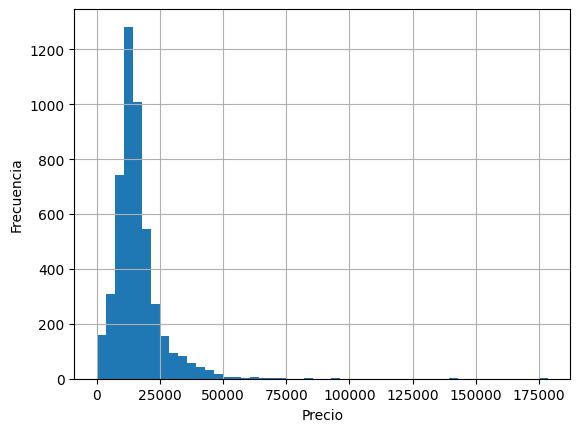

In [345]:
df_inicial_test.precio.hist(bins=50)
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

In [346]:
def columnas_por_tipo(df, as_dict=False):
    """
    Agrupa las columnas de un DataFrame por tipo y devuelve las listas de nombres de columnas.

    Parámetros:
    - df: pandas.DataFrame
    - as_dict: bool (opcional). Si True devuelve un dict con las listas;
               si False (por defecto) devuelve una tupla con las listas en el
               siguiente orden: (numeric, bools, datetimes, objects, categories,
               timedeltas, complex_cols, ints, floats, others).

    Retorno:
    - Si as_dict=True: dict con claves 'all','numeric','int','float','bool',
      'datetime','object','category','timedelta','complex','others'.
    - Si as_dict=False: tupla de listas: (numeric, bools, datetimes, objects,
      categories, timedeltas, complex_cols, ints, floats, others).

    Ejemplos:
    - numeric, bools, datetimes, objects, categories, timedeltas, complex_cols,
      ints, floats, others = columnas_por_tipo(df)
    - grouped = columnas_por_tipo(df, as_dict=True)
    - df[numeric].head()  # muestra solo columnas numéricas si 'numeric' es la lista
    """
    # columnas por tipos básicos
    numeric = df.select_dtypes(include=['number']).columns.tolist()
    bools = df.select_dtypes(include=['bool']).columns.tolist()
    datetimes = df.select_dtypes(include=['datetime']).columns.tolist()
    objects = df.select_dtypes(include=['object']).columns.tolist()
    categories = df.select_dtypes(include=['category']).columns.tolist()
    timedeltas = df.select_dtypes(include=['timedelta']).columns.tolist()
    complex_cols = df.select_dtypes(include=['complex']).columns.tolist()

    # distinguir int / float dentro de numeric
    ints = [c for c in numeric if pd.api.types.is_integer_dtype(df[c])]
    floats = [c for c in numeric if pd.api.types.is_float_dtype(df[c])]

    grouped = {
        'all': df.columns.tolist(),
        'numeric': numeric,
        'int': ints,
        'float': floats,
        'bool': bools,
        'datetime': datetimes,
        'object': objects,
        'category': categories,
        'timedelta': timedeltas,
        'complex': complex_cols,
    }

    # columnas que no encajan en los grupos anteriores
    grouped_lists = [grouped[k] for k in ['numeric','int','float','bool','datetime','object','category','timedelta','complex']]
    used = set().union(*map(set, grouped_lists)) if grouped_lists else set()
    grouped['others'] = [c for c in df.columns if c not in used]

    if as_dict:
        return grouped

    # devolver las listas en un orden fijo para permitir unpacking directo
    return (numeric, bools, datetimes, objects, categories, timedeltas,
            complex_cols, ints, floats, grouped['others'])

In [347]:
grouped_columns = columnas_por_tipo(df_inicial_test, as_dict=True)
for tipo, columnas in grouped_columns.items():
    print(f"{tipo}: {columnas}")

all: ['modelo', 'km', 'potencia', 'fecha_registro', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad', 'precio', 'fecha_venta']
numeric: ['km', 'potencia', 'precio']
int: []
float: ['km', 'potencia', 'precio']
bool: ['gps']
datetime: ['fecha_registro', 'fecha_venta']
object: ['modelo', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'alerta_lim_velocidad']
category: []
timedelta: []
complex: []
others: []


In [348]:
numeric, bools, datetimes, objects, categories, timedeltas, complex_cols, ints, floats, others = columnas_por_tipo(df_inicial_test)
df_inicial_test[numeric].head()

,km,potencia,precio
0,140411.0,100.0,11300.0
1,13929.0,317.0,69700.0
2,183297.0,120.0,10200.0
3,128035.0,135.0,25100.0
4,97097.0,160.0,33400.0


In [349]:
def imputar_por_similitud(df, target_col, numeric_cols, cat_bool_cols, umbral_dominancia=0.75, margen_global=0.05, usar_percentiles=False, estrategia='moda'):
    """
        Imputa valores nulos en una columna objetivo basándose en la similitud con otros registros (vecinos).
        
        Esta función busca filas similares a aquellas que tienen datos faltantes en `target_col`. 
        La similitud se define mediante coincidencias exactas en variables categóricas/booleanas 
        y proximidad dentro de un margen en variables numéricas.

        Lógica de búsqueda de vecinos:
        1. Filtro estricto: Debe coincidir el valor en todas las columnas de `cat_bool_cols`.
        2. Filtro numérico: El valor debe estar dentro de un rango (margen) definido para `numeric_cols`.
        - Si `usar_percentiles=False`: Rango = valor ± (valor * margen).
        - Si `usar_percentiles=True`: Rango = percentiles correspondientes al (rank_actual ± margen).

        Args:
            df (pd.DataFrame): DataFrame original conteniendo los datos.
            target_col (str): Nombre de la columna que contiene los valores nulos a imputar.
            numeric_cols (list o dict): 
                - Si es lista: Columnas numéricas para comparar similitud usando `margen_global`.
                - Si es dict: Claves son columnas y valores son el margen específico para esa columna (ej. {'edad': 0.1}).
            cat_bool_cols (list): Lista de columnas categóricas o booleanas para coincidencia exacta (Hard matching).
            umbral_dominancia (float, opcional): Solo para estrategia 'moda'. Porcentaje mínimo de coincidencia 
                entre vecinos para aceptar la imputación (defecto 0.75).
            margen_global (float, opcional): Tolerancia por defecto para la comparación numérica (defecto 0.05 o 5%).
            usar_percentiles (bool, opcional): Define cómo se calcula el margen numérico. 
                False usa distancia relativa al valor; True usa distancia en la distribución (quantiles).
            estrategia (str, opcional): Método de agregación de los vecinos encontrados.
                - 'moda': Valor más frecuente (requiere cumplir `umbral_dominancia`).
                - 'mediana': Mediana de los vecinos (soporta números y fechas).
                - 'media': Promedio aritmético (solo números).

        Returns:
            pd.DataFrame: Una copia del DataFrame original con los valores imputados donde fue posible.
    """

    df_out = df.copy()
    
    if df_out[target_col].isnull().sum() == 0:
        return df_out

    filas_nulas = df_out[df_out[target_col].isnull()]
    print(f"Procesando {len(filas_nulas)} nulos en '{target_col}' | Estrategia: {estrategia} | Percentiles: {usar_percentiles}...")
    
    imputaciones = 0
    
    # Pre-procesamiento config numérica
    if isinstance(numeric_cols, list):
        numeric_config = {col: margen_global for col in numeric_cols}
    else:
        numeric_config = numeric_cols

    for idx, row in filas_nulas.iterrows():
        mask = pd.Series([True] * len(df), index=df.index)
        
        # 1. Filtros
        for col in cat_bool_cols:
            valor = row[col]
            if not pd.isna(valor):
                mask &= (df[col] == valor)
        
        for col, margen_especifico in numeric_config.items():
            valor = row[col]
            if not pd.isna(valor):
                if usar_percentiles:
                    # Lógica Percentil
                    rank_actual = (df[col] < valor).mean()
                    q_min = max(0, rank_actual - margen_especifico)
                    q_max = min(1, rank_actual + margen_especifico)
                    try:
                        lim_inf = df[col].quantile(q_min)
                        lim_sup = df[col].quantile(q_max)
                        mask &= (df[col].between(lim_inf, lim_sup))
                    except: pass
                else:
                    # Lógica Rango Fijo
                    try:
                        lim_inf = valor * (1 - margen_especifico)
                        lim_sup = valor * (1 + margen_especifico)
                        if valor < 0: lim_inf, lim_sup = lim_sup, lim_inf
                        mask &= (df[col].between(lim_inf, lim_sup))
                    except: pass

        mask &= (df.index != idx)
        vecinos = df.loc[mask, target_col]
        
        if vecinos.empty:
            continue
            
        # 2. DECISIÓN SEGÚN ESTRATEGIA
        valor_imputado = None
        
        if estrategia == 'moda':
            # Lógica original: Requiere consenso
            conteo = vecinos.value_counts(normalize=True)
            if not conteo.empty:
                if conteo.iloc[0] >= umbral_dominancia:
                    valor_imputado = conteo.index[0]
        
        elif estrategia == 'mediana':
            # Lógica numérica/fechas: Valor central
            # Para fechas, convertimos a numérico, calculamos mediana y reconvertimos
            if pd.api.types.is_datetime64_any_dtype(vecinos):
                mediana_num = vecinos.astype(np.int64).median()
                valor_imputado = pd.to_datetime(mediana_num)
            else:
                valor_imputado = vecinos.median()
                
        elif estrategia == 'media':
             if pd.api.types.is_numeric_dtype(vecinos):
                valor_imputado = vecinos.mean()

        # 3. Asignación
        if valor_imputado is not None:
            df_out.at[idx, target_col] = valor_imputado
            imputaciones += 1

    print(f"Terminado: Se imputaron {imputaciones} de {len(filas_nulas)} ({round(imputaciones/len(filas_nulas)*100, 2)}%).")
    return df_out

In [350]:
import sys
import os
import importlib

# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python
sys.path.append(src_path)

# Ahora ya puedes importar
import utils
importlib.reload(utils)  # Forzar recarga si ya se había importado antes

df_inicial_test_2 = df_inicial_test.copy()
df_inicial_test_2.info()
df_inicial_test_2 = df_inicial_test_2.dropna(subset=['precio'])
# df_inicial_test_2 = df_inicial_test_2.drop(columns=['marca','asientos_traseros_plegables'])
df_inicial_test_2 = df_inicial_test_2.fillna({'color': 'desconocido'})
df_inicial_test_2['tipo_gasolina'] = df_inicial_test_2['tipo_gasolina'].str.lower()
df_inicial_test_2.loc[(df_inicial_test_2['modelo'] == 'X3') & (df_inicial_test_2['tipo_coche'] == 'van'),'tipo_coche'] = 'suv'
# null = utils.auditoria_nulos(df_inicial_test_2)
df_inicial_test_knn = df_inicial_test_2.copy()

target_equipamiento = ['aire_acondicionado', 'camara_trasera', 'elevalunas_electrico', 
                       'bluetooth', 'alerta_lim_velocidad', 'volante_regulable']
target_estructural = ['modelo', 'tipo_coche', 'tipo_gasolina']
target_fechas = ['fecha_registro', 'fecha_venta'] # A estos les aplicaremos mediana

# config_strict = {'potencia': 0.05, 'km': 0.20, 'precio': 0.10}
config_strict = {'potencia': 0.01, 'km': 0.10}


for col in target_equipamiento:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_strict,
        cat_bool_cols=['modelo', 'tipo_gasolina', 'tipo_coche'],
        umbral_dominancia=0.70, estrategia='moda' # MODA para equipamiento
    )

for col in target_estructural:
    preds = [c for c in target_estructural if c != col]
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_strict,
        cat_bool_cols=preds, umbral_dominancia=0.70, estrategia='moda' # MODA para categóricas
    )

config_relaxed = {'potencia': 0.01, 'km': 0.30}

for _ in range(2): 
    for col in target_estructural:
        preds = [c for c in target_estructural if c != col]
        df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col=col, numeric_cols=config_relaxed,
            cat_bool_cols=preds, umbral_dominancia=0.50, estrategia='moda'
        )

for col in target_equipamiento:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_relaxed,
        cat_bool_cols=['modelo', 'tipo_coche'], umbral_dominancia=0.55, estrategia='moda'
    )

# Aquí cambiamos a MEDIANA
config_fechas = {'potencia': 0.10, 'km': 0.10}

for col in target_fechas:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col,
        numeric_cols=config_fechas,
        cat_bool_cols=['modelo', 'tipo_coche'],
        usar_percentiles=True,
        estrategia='mediana'
    )

# Buscamos solo por KM (desgaste) y aplicamos mediana
config_fechas_fallback = {'km': 0.05} 

for col in target_fechas:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col,
        numeric_cols=config_fechas_fallback,
        cat_bool_cols=[], # Sin filtros categóricos
        usar_percentiles=True,
        estrategia='mediana'
    )

# Si quedan KM o Potencia vacíos, también deberíamos usar Mediana en una pasada final
if df_inicial_test_knn['km'].isnull().sum() > 0:
     df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col='km', numeric_cols={'potencia': 0.10}, 
        cat_bool_cols=['modelo', 'tipo_coche'], estrategia='mediana'
    )

df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col='modelo', numeric_cols=config_relaxed,
            cat_bool_cols=preds, umbral_dominancia=0.30, estrategia='moda',
            usar_percentiles=True
        )

df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col='tipo_coche', numeric_cols={'precio': 1.0},
            cat_bool_cols=['modelo'], umbral_dominancia=0.40, estrategia='moda',
            usar_percentiles=True
        )

df_inicial_test_knn[target_equipamiento] = df_inicial_test_knn[target_equipamiento].fillna(False)

df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col='potencia', numeric_cols={'precio': 1.0},
            cat_bool_cols=['modelo'], umbral_dominancia=0.40, estrategia='moda',
            usar_percentiles=False
        )

for col in df_inicial_test_knn.columns:
    if str(col).upper().startswith('FECHA'):
        # 1. Aseguramos que sea datetime (ignora errores si ya hay NaTs)
        df_inicial_test_knn[col] = pd.to_datetime(df_inicial_test_knn[col], errors='coerce')
        # 2. Convertimos a timestamp mensual para evitar problemas de horas/minutos/segundos
        df_inicial_test_knn[col] = df_inicial_test_knn[col].dt.to_period('M').dt.to_timestamp()

     
df_inicial_test_knn_2 = df_inicial_test_knn.copy()

df_limpio = df_inicial_test_knn[df_inicial_test_knn.isnull().sum(axis=1) <= 1].copy()
display(utils.auditoria_nulos(df_limpio))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

KeyboardInterrupt: 

In [ ]:
df_inicial.shape, df_limpio.shape

((4843, 18), (4837, 17))

In [ ]:
df_limpio[df_limpio['potencia'] <= 60.0]

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
1796,i3,152328.0,25.0,2012-06-01,hybrid_petrol,black,hatchback,False,True,False,NaN,False,False,True,True,20300.0,2018-04-01
1925,i3,152470.0,25.0,2012-06-01,hybrid_petrol,black,hatchback,False,True,False,NaN,False,False,True,True,15500.0,2018-03-01
3765,X1,81770.0,0.0,2014-10-01,diesel,white,suv,False,False,False,False,False,False,False,False,11700.0,2018-03-01


In [ ]:
df_limpio[df_limpio['modelo'] == 'i3']['potencia'].value_counts()

potencia
75.0     3
25.0     2
125.0    1
Name: count, dtype: int64

In [ ]:
df_limpio[df_limpio['modelo'] == 'X1']['potencia'].value_counts(normalize=True)

potencia
105.0    0.334545
100.0    0.196364
85.0     0.130909
135.0    0.120000
120.0    0.112727
130.0    0.047273
160.0    0.032727
150.0    0.010909
110.0    0.007273
0.0      0.003636
137.0    0.003636
Name: proportion, dtype: float64

In [ ]:
df_limpio[df_limpio['modelo'] == 'X1']['potencia'].median()

np.float64(105.0)

In [ ]:
df_test = df_limpio.copy()
df_test["DIF_TIEMPO"] = df_limpio["fecha_venta"] - df_limpio["fecha_registro"]
df_test["DIF_TIEMPO"].mean().days / 365.25

12.922655715263518

In [ ]:
df_limpio['precio'].quantile(0.90)

np.float64(25800.0)

## PREGUNTA 1

In [ ]:
## 1. ¿Qué columnas eliminaron inicialmente del dataset y por qué?

In [ ]:
## Kike Se elimino la columna MARCA al ser todo el data set de la marca BMW

In [ ]:
## Kike defino target. TARGET = "precio"

## PREGUNTA 2

In [ ]:
## 2. Manejo de nulos, explicar qué se hizo con los nulos por cada columna

In [ ]:
# Kike Porcentaje de nulos
for i in df_inicial_test.columns:
    prctj = df_inicial_test[i].isnull().mean() * 100
    print(f'{prctj:.3f}% \tde nulos en {i}')

NameError: name 'df_inicial_test' is not defined

/tmp/ipython-input-2873952471.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="anio_registro", y="precio", data=df_inicial_test, palette="Wistia")


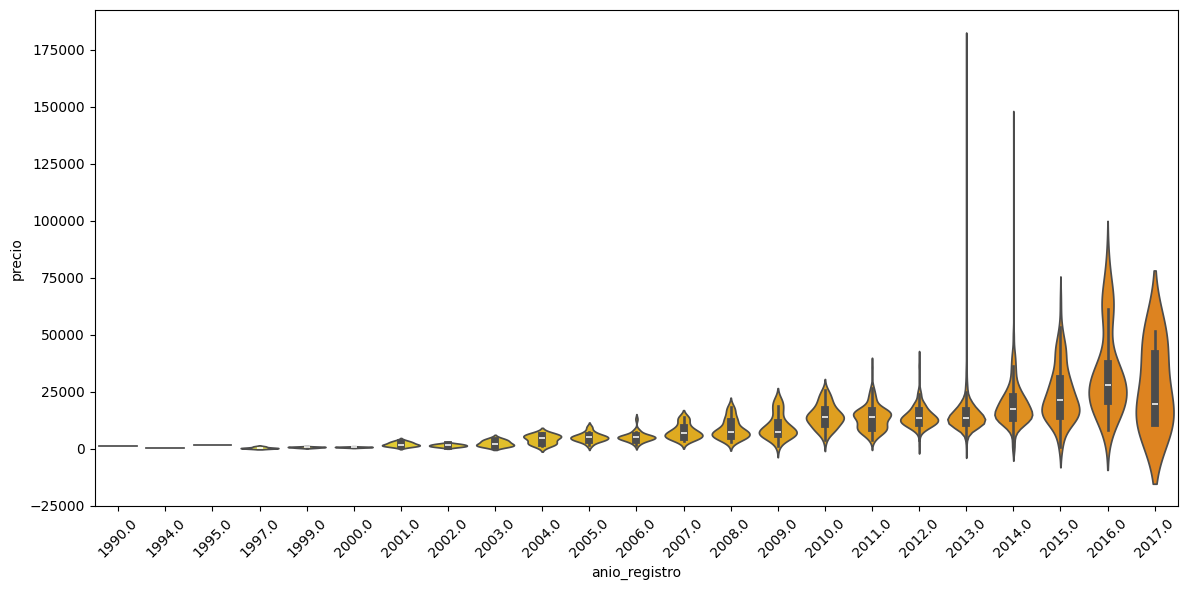

In [ ]:
## Kike Vemos si fecha de registro incide en target
## Kike Este código es para transformar en años
df_inicial_test["fecha_registro"] = pd.to_datetime(
    df_inicial_test["fecha_registro"], errors='coerce'
)

df_inicial_test["anio_registro"] = df_inicial_test["fecha_registro"].dt.year


plt.figure(figsize=(12,6))
sns.violinplot(x="anio_registro", y="precio", data=df_inicial_test, palette="Wistia")
plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
## Kike Esta es la propuesta:
## 20.03% 	de nulos en marca. Eliminar variable
## 0.06% 	de nulos en modelo
## 0.04% 	de nulos en km
## 0.02% 	de nulos en potencia
## 50.03% 	de nulos en fecha_registro
## 0.10% 	de nulos en tipo_gasolina
## 9.19% 	de nulos en color
## 30.15% 	de nulos en tipo_coche
## 0.08% 	de nulos en volante_regulable
## 10.04% 	de nulos en aire_acondicionado
## 0.04% 	de nulos en camara_trasera
## 70.02% 	de nulos en asientos_traseros_plegables
## 0.04% 	de nulos en elevalunas_electrico
## 15.03% 	de nulos en bluetooth
## 0.00% 	de nulos en gps
## 15.03% 	de nulos en alerta_lim_velocidad
## 0.12% 	de nulos en precio
## 0.02% 	de nulos en fecha_venta
##Kike
## Marca, eliminar variable. Son todos BMW
## Fecha registro, muchos nulos, incide en target. Pondría 0 si conozco antigüedad y 1 : no la conozco
## Asientos traseros plegables, muchos nulos, poner que no tiene. bool:0
## Entre 10%-50%, objetc:"desconocido", bool:0
## <1%. No afectan modelo. objet: "desconocido", float:mediana, bool:0
## Target precio. No se imputan, se eliminan filas

## PREGUNTA 3

In [ ]:
## 3. Análisis univariable, explicar alguna información interesante encontrada

In [ ]:
df_inicial_test.info()
## Kike
# No hay duplicados
# Se cambia a dates los atributos de fechas.
# Los nulos se contestaron en pregunta anterior.
# Outliers en precio (haría LOG), en potencia y km. Ver más abajo y habría que decidir qué hacer con ellos.
## Hay km negativos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

In [ ]:
df_inicial_test.describe(include = ['object']).T

,count,unique,top,freq
modelo,4840,76,320,752
tipo_gasolina,4838,5,diesel,4631
color,4398,10,black,1499
tipo_coche,3383,8,estate,1107
volante_regulable,4839,2,True,2662
aire_acondicionado,4357,2,True,3465
camara_trasera,4841,2,False,3864
asientos_traseros_plegables,1452,2,False,1150
elevalunas_electrico,4841,2,False,2612
bluetooth,4115,2,False,3119


In [ ]:
df_inicial_test.describe(exclude = ['object']).T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
km,4841.0,NaN,NaN,NaN,140959.347862,-64.0,102884.0,141080.0,175217.0,1000376.0,60208.534313
potencia,4842.0,NaN,NaN,NaN,128.981826,0.0,100.0,120.0,135.0,423.0,38.994839
fecha_registro,2420,NaN,NaN,NaN,2012-12-06 07:35:12.396694016,1990-03-01 00:00:00,2012-07-01 00:00:00,2013-07-01 00:00:00,2014-04-01 00:00:00,2017-11-01 00:00:00,NaN
gps,4843,2,True,4514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio,4837.0,NaN,NaN,NaN,15831.920612,100.0,10800.0,14200.0,18600.0,178500.0,9222.630708
fecha_venta,4842,NaN,NaN,NaN,2018-04-26 11:45:07.806691584,2007-08-01 00:00:00,2018-03-01 00:00:00,2018-05-01 00:00:00,2018-07-01 00:00:00,2018-09-01 00:00:00,NaN
anio_registro,2420.0,NaN,NaN,NaN,2012.507438,1990.0,2012.0,2013.0,2014.0,2017.0,2.497362


Text(0, 0.5, 'Frecuencia')

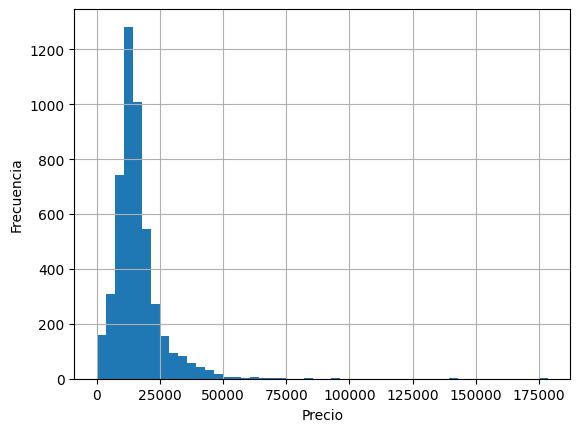

In [ ]:
## Kike El precio tiene 2 outliers. Quizás sea necesario un LOG

df_inicial_test.precio.hist(bins=50)
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

<Axes: xlabel='precio'>

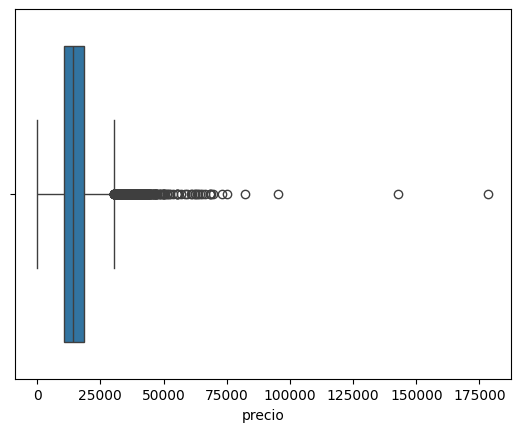

In [ ]:
sns.boxplot(x=df_inicial_test["precio"])

<Axes: xlabel='km'>

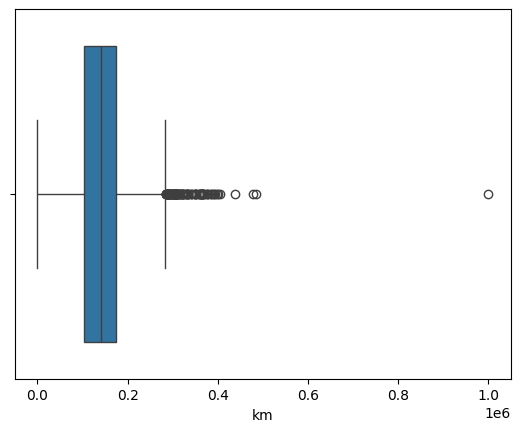

In [ ]:
## Kike Miro outliers en km y potencia según describe. Hay un outlier en km y dos en potencia

sns.boxplot(x=df_inicial_test["km"])

<Axes: xlabel='potencia'>

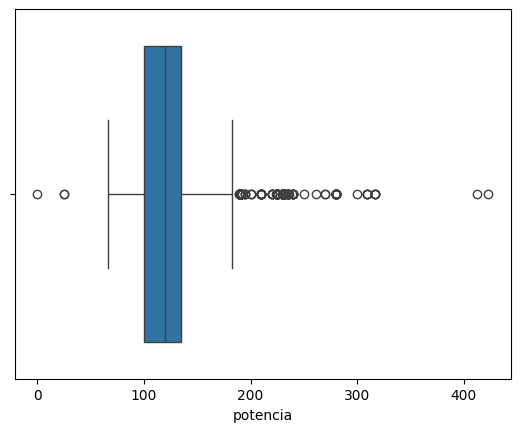

In [ ]:
sns.boxplot(x=df_inicial_test["potencia"])

## PREGUNTA 4

In [ ]:
## 4. Análisis de correlación inicial, ¿Hay alguna variable correlacionada?

In [ ]:
utils.analizar_correlaciones_productos(df_limpio, 'precio', agrupar=True, clave_agrupar='modelo')

Agrupando por modelo


TypeError: Series.corr() missing 1 required positional argument: 'other'

In [ ]:
def analizar_correlaciones(df, cols_analisis, agrupar=False, clave_agrupar=None, metodo_agrupacion='mean'):
    """
    Genera un Mapa de Calor (Heatmap) de correlaciones (Pearson) para columnas numéricas o booleanas.
    
    Parámetros:
    - df: DataFrame.
    - cols_analisis: Lista de las columnas a relacionar.
    - agrupar: (Bool) Si True, agrupa los datos antes de correlacionar.
    - clave_agrupar: (Opcional) Columna para agrupar (ej. 'cliente_id').
    - metodo_agrupacion: 'mean' (promedio, recomendado numéricas) o 'max' (binario estricto).
    """
    
    # Copia para no alterar original
    df_temp = df.copy()

    # 1. Gestión de Agrupación
    if agrupar:
        # Auto-detectar clave si no se pasa
        if clave_agrupar is None:
            # Busca primera columna que empiece por 'pk_' y no sea partition
            posibles_pks = [c for c in df_temp.columns if 'pk_' in c and c != 'pk_partition']
            if posibles_pks:
                clave_agrupar = posibles_pks[0]
            else:
                raise ValueError("No se encontró 'pk_' automática. Especifica 'clave_agrupar'.")
        
        print(f"Agrupando por: {clave_agrupar} usando método: {metodo_agrupacion}")
        
        # Agrupar
        if metodo_agrupacion == 'max':
            df_analisis = df_temp.groupby(clave_agrupar)[cols_analisis].max()
        else:
            df_analisis = df_temp.groupby(clave_agrupar)[cols_analisis].mean()
            
    else:
        # Sin agrupar: análisis directo de filas
        df_analisis = df_temp[cols_analisis]

    # 2. Cálculo de la Correlación
    corr_matrix = df_analisis.corr(method='pearson')
    
    # 3. Diseño del Gráfico
    plt.figure(figsize=(14, 12))
    
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu',      # Rojo (inversa) - Blanco (neutro) - Azul (directa)
        vmin=-1, vmax=1,  # Rango completo para numéricas
        center=0, 
        linewidths=0.5, 
        cbar_kws={"shrink": .5}
    )
    
    titulo = f"Matriz de Correlación ({'Agrupada' if agrupar else 'Directa'})"
    plt.title(titulo, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

In [ ]:
def aplanar_lista(elementos):
    lista_plana = []
    for item in elementos:
        if isinstance(item, list):
            lista_plana.extend(item) # Si es lista, añade sus elementos
        else:
            lista_plana.append(item) # Si es texto, lo añade directamente
    return lista_plana

# 2. Creamos la lista pasando los elementos crudos (sin sumar con +)
lista_elementos = [columnas_numericas, target_equipamiento, 'precio']
cols_finales = aplanar_lista(lista_elementos)

# 3. Verificamos (opcional)
print("Columnas finales:", cols_finales)

Columnas finales: ['km', 'potencia', 'aire_acondicionado', 'camara_trasera', 'elevalunas_electrico', 'bluetooth', 'alerta_lim_velocidad', 'volante_regulable', 'precio']


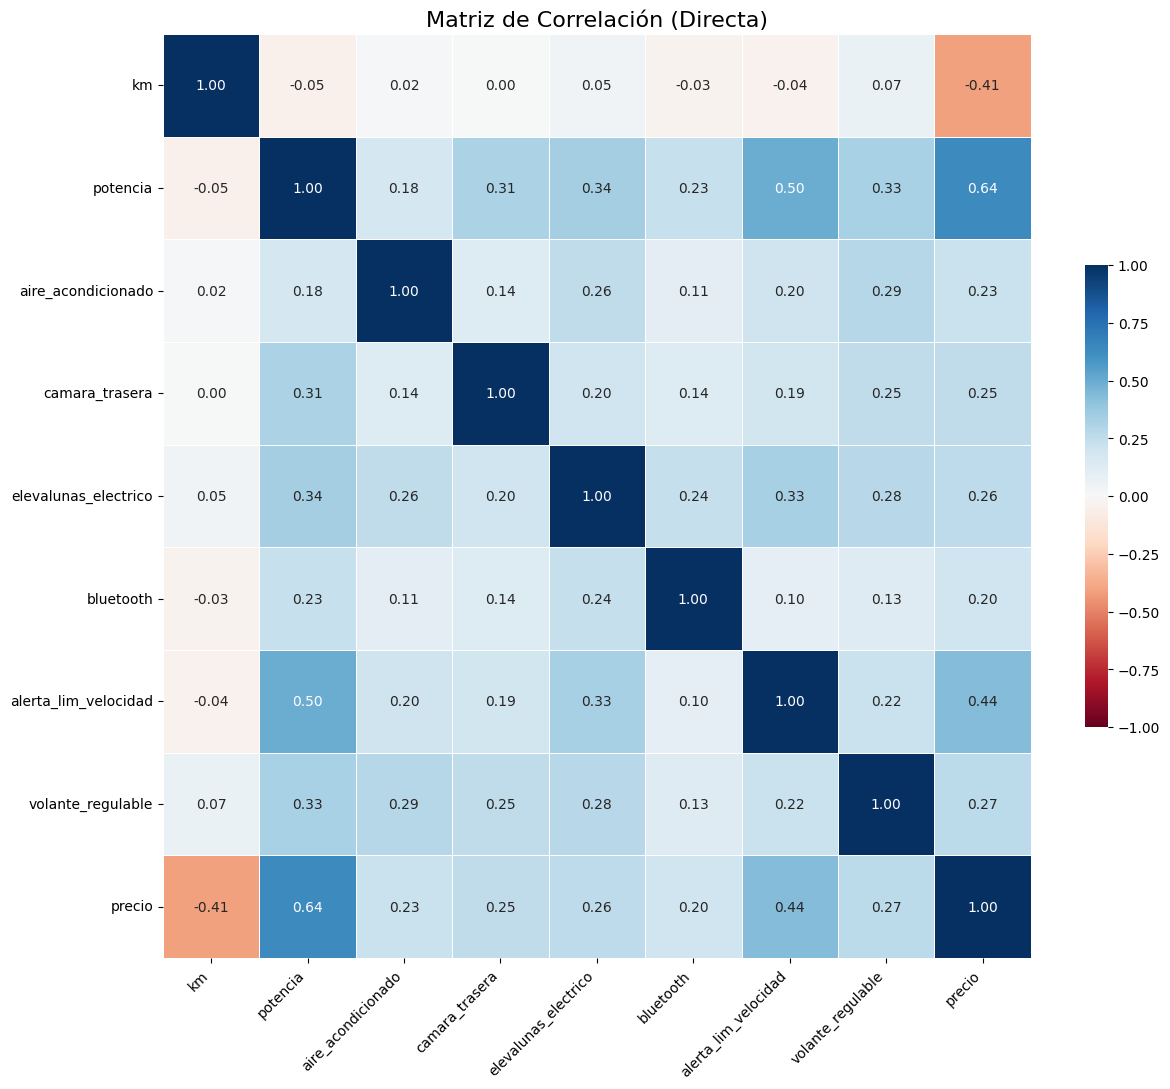

In [ ]:
analizar_correlaciones(df_limpio, cols_finales)

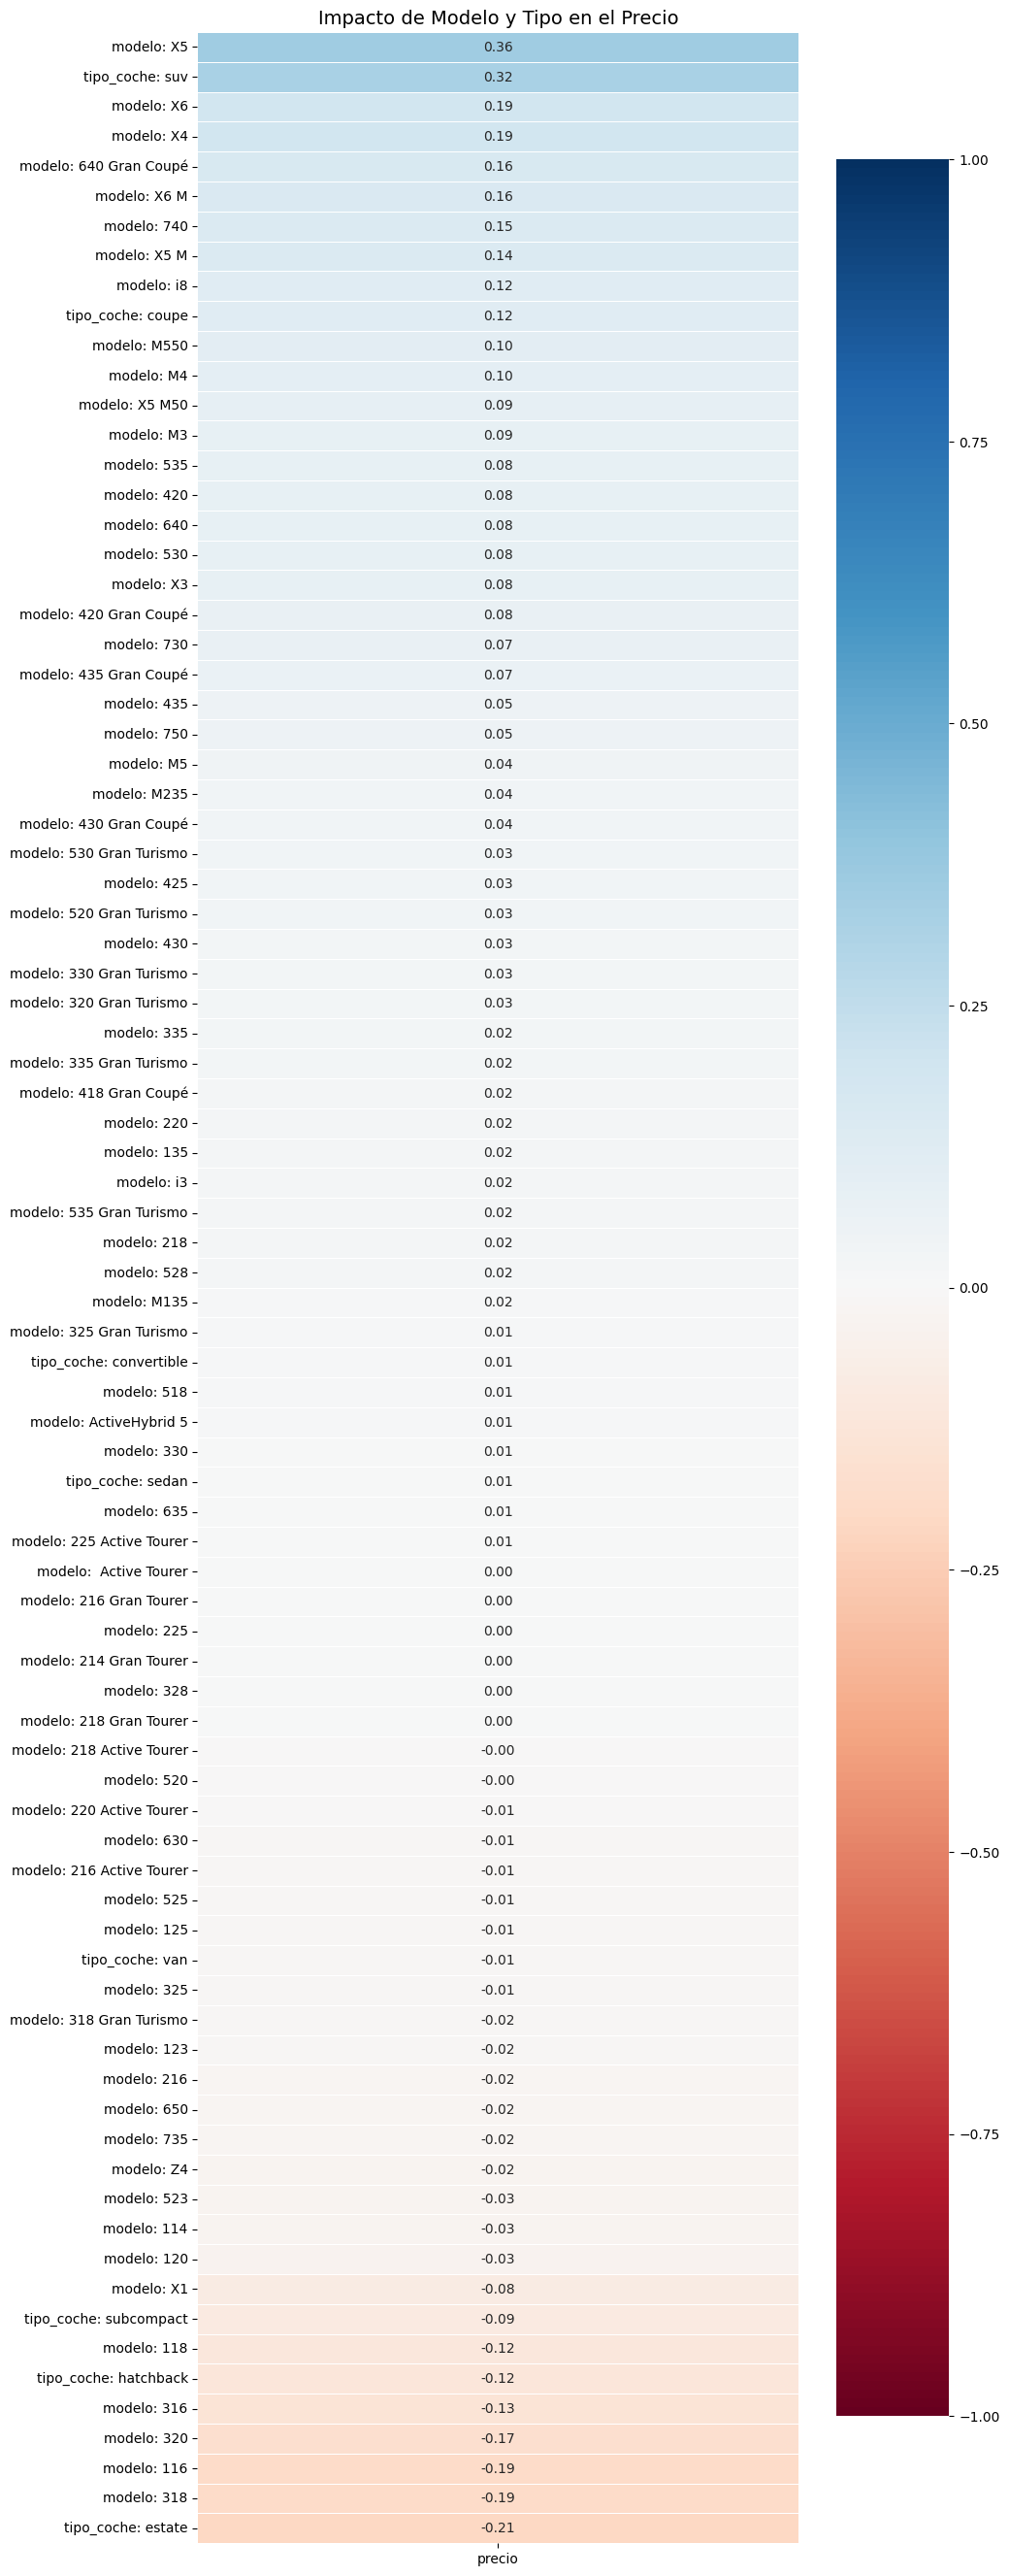

In [ ]:
cols_categoricas = ['modelo', 'tipo_coche']
target = 'precio'

# 2. Creamos las variables dummy (0 y 1) para los textos
# drop_first=False para ver todas las categorías explícitamente
df_dummies = pd.get_dummies(df_limpio[cols_categoricas], prefix_sep=': ')

# 3. Añadimos el precio al dataframe de dummies
df_analisis = pd.concat([df_dummies, df_limpio[target]], axis=1)

# 4. Calculamos la correlación SOLO contra el precio (para no hacer una matriz gigante ilegible)
correlaciones_precio = df_analisis.corr(method='pearson')[[target]]

# 5. Ordenamos de mayor a menor impacto y quitamos la fila de 'precio' contra sí mismo
correlaciones_precio = correlaciones_precio.drop(index=target).sort_values(by=target, ascending=False)

# --- GRÁFICO ---
plt.figure(figsize=(10, len(correlaciones_precio) * 0.4)) # Altura dinámica según cantidad de modelos

# Usamos un heatmap de una sola columna para ver el impacto visualmente
sns.heatmap(correlaciones_precio, 
            annot=True, 
            cmap='RdBu', 
            vmin=-1, vmax=1, 
            fmt='.2f',
            linewidths=0.5)

plt.title('Impacto de Modelo y Tipo en el Precio', fontsize=14)
plt.show()

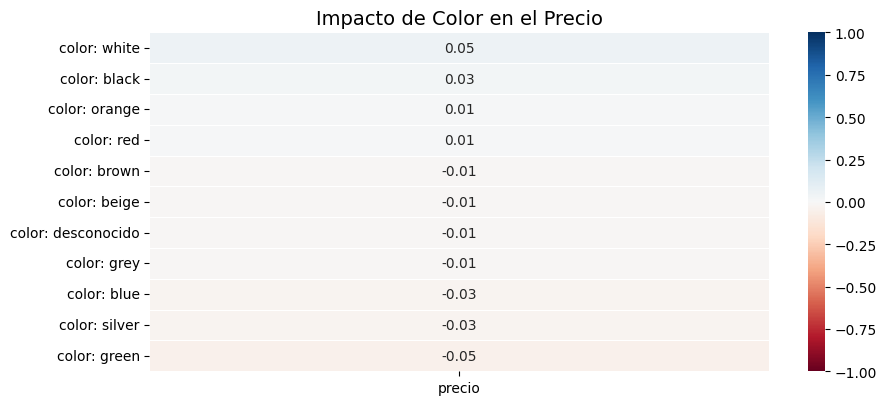

In [ ]:
ols_categoricas = ['color']
target = 'precio'

# 2. Creamos las variables dummy (0 y 1) para los textos
# drop_first=False para ver todas las categorías explícitamente
df_dummies = pd.get_dummies(df_limpio[ols_categoricas], prefix_sep=': ')

# 3. Añadimos el precio al dataframe de dummies
df_analisis = pd.concat([df_dummies, df_limpio[target]], axis=1)

# 4. Calculamos la correlación SOLO contra el precio (para no hacer una matriz gigante ilegible)
correlaciones_precio = df_analisis.corr(method='pearson')[[target]]

# 5. Ordenamos de mayor a menor impacto y quitamos la fila de 'precio' contra sí mismo
correlaciones_precio = correlaciones_precio.drop(index=target).sort_values(by=target, ascending=False)

# --- GRÁFICO ---
plt.figure(figsize=(10, len(correlaciones_precio) * 0.4)) # Altura dinámica según cantidad de modelos

# Usamos un heatmap de una sola columna para ver el impacto visualmente
sns.heatmap(correlaciones_precio, 
            annot=True, 
            cmap='RdBu', 
            vmin=-1, vmax=1, 
            fmt='.2f',
            linewidths=0.5)

plt.title('Impacto de Color en el Precio', fontsize=14)
plt.show()

In [ ]:
## Kike Miramos correlaciones entre variables numericas. Nada a destacar, precio y km son casi opuestas
## Kike Habría que pasar las categóricas a numéricas, pero lo pide en la pregunta 6.

corr=df_inicial_test.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm')

,km,potencia,gps,precio,anio_registro
km,1.000000,-0.050141,0.154815,-0.410189,-0.483464
potencia,-0.050141,1.000000,0.008862,0.639254,0.092517
gps,0.154815,0.008862,1.000000,-0.005227,-0.077771
precio,-0.410189,0.639254,-0.005227,1.000000,0.427901
anio_registro,-0.483464,0.092517,-0.077771,0.427901,1.000000


## PREGUNTA 5

In [ ]:
## 5. Análisis variable vs target, ¿Hay algún insight interesante?

In [ ]:
df_inicial_test.info()
## Kike annio está en float, debe pasarse a datetime64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

In [ ]:
## Kike Paso annio_registro a datetime
df_inicial_test["anio_registro"] = pd.to_datetime(df_inicial_test["anio_registro"])

df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

In [ ]:
df_inicial_test["modelo"].unique()

array(['118', 'M4', '320', '420', '425', '335', '325', 'Z4', '120', '220',
       '650', '135', '218', '318', '430', 'M3', '330', '225', 'M235',
       '316', '435', '640', '640 Gran Coupé', '435 Gran Coupé', 'i8',
       '630', '430 Gran Coupé', '635', '520', nan, '525', '530', '535',
       '320 Gran Turismo', '518', '116', '328', '523', 'X3', 'M550',
       '528', '325 Gran Turismo', '125', '318 Gran Turismo',
       '420 Gran Coupé', 'i3', '114', '520 Gran Turismo',
       '530 Gran Turismo', 'M135', '418 Gran Coupé', '330 Gran Turismo',
       '335 Gran Turismo', '730', '123', '535 Gran Turismo', '740', '750',
       'ActiveHybrid 5', '735', 'M5', 'X5', 'X1', 'X4', 'X6', 'X6 M',
       'X5 M', 'X5 M50', '218 Active Tourer', '218 Gran Tourer', '216',
       '220 Active Tourer', '216 Gran Tourer', '216 Active Tourer',
       ' Active Tourer', '225 Active Tourer', '214 Gran Tourer'],
      dtype=object)

In [ ]:
## Kike listo toda las variables con sus valores únicos
for i in df_inicial_test:
  print(i,"\n\n",df_inicial_test[i].value_counts(),"\n\n")

modelo 

 modelo
320                  752
520                  633
318                  568
X3                   438
116                  358
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 76, dtype: int64 


km 

 km
129317.0    2
129214.0    2
193202.0    2
72760.0     2
188713.0    2
           ..
193231.0    1
84058.0     1
303225.0    1
205603.0    1
87542.0     1
Name: count, Length: 4784, dtype: int64 


potencia 

 potencia
135.0    882
120.0    785
85.0     631
100.0    570
105.0    451
        ... 
412.0      1
0.0        1
423.0      1
300.0      1
261.0      1
Name: count, Length: 61, dtype: int64 


fecha_registro 

 fecha_registro
2013-07-01    93
2014-03-01    83
2014-05-01    81
2013-01-01    78
2013-10-01    77
              ..
2004-11-01     1
2009-12-01     1
2005-02-01     1
2004-06-01     1
2005-09-01     1
Name: count, Length: 180, dtype: int

In [ ]:
## Kike Defino target
target = ["precio"]

In [ ]:
## Kike Paso variable gps booleana a int
df_inicial_test["gps_bool"] = df_inicial_test["gps"].astype(int)
df_inicial_test.drop(columns=["gps"], inplace=True)
df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

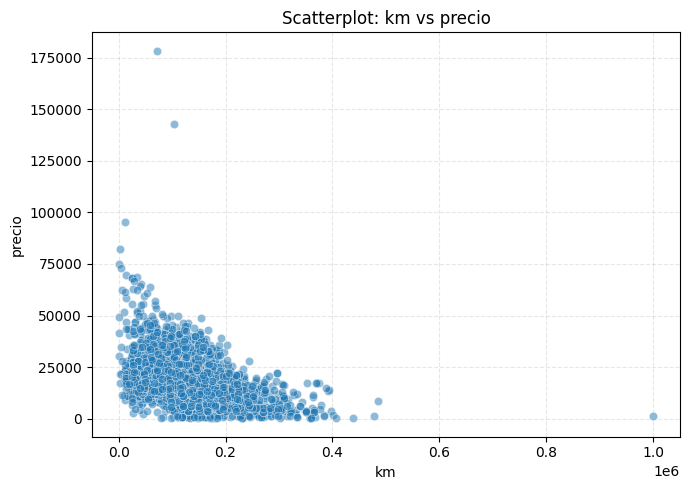

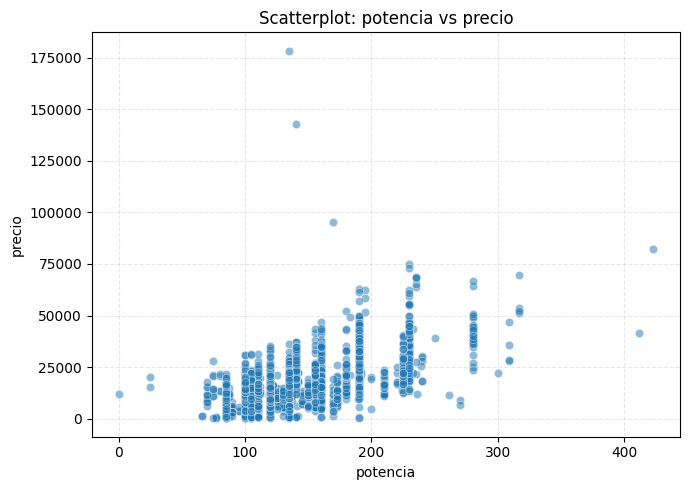

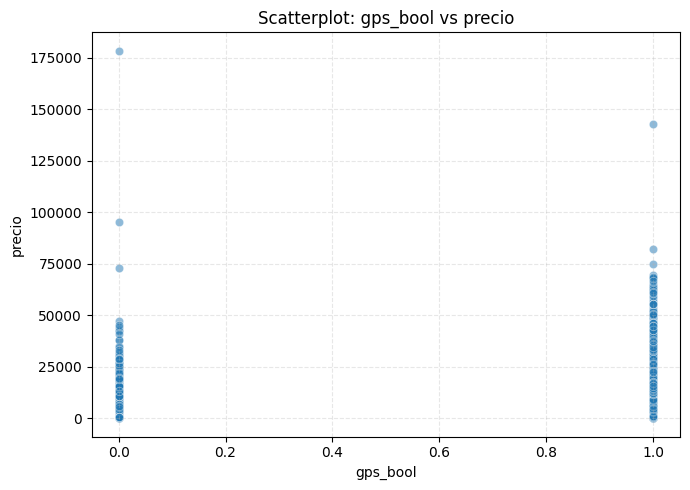

In [ ]:
## Kike Variables numericas con target con scatterplot
## Kike Conclusion: a más km, menos precio y a más potencia, más precio. Con gps son más caros.
## Kike Seleccionar columnas numéricas

num_cols = df_inicial_test.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col == "precio":   # evitar comparar el target consigo mismo
        continue

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=df_inicial_test[col], y=df_inicial_test["precio"], alpha=0.5)
    plt.title(f"Scatterplot: {col} vs precio")
    plt.xlabel(col)
    plt.ylabel("precio")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


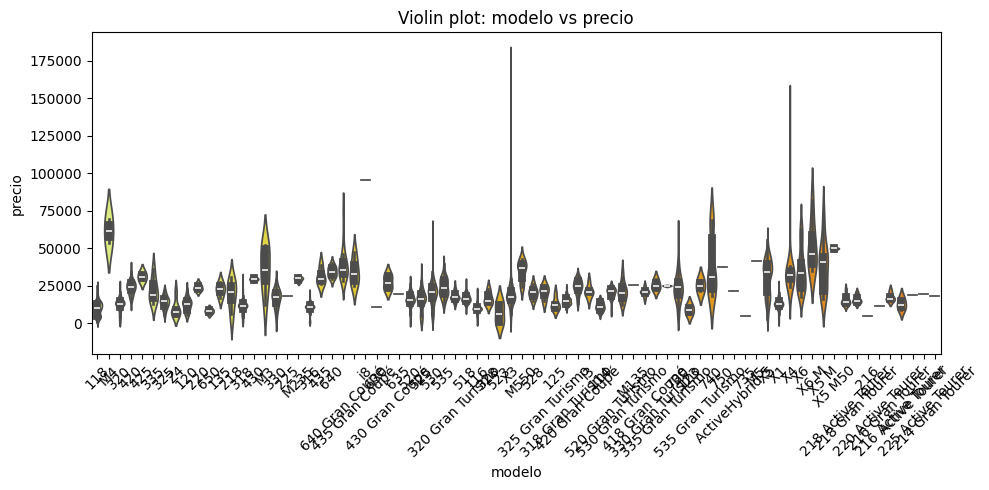

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


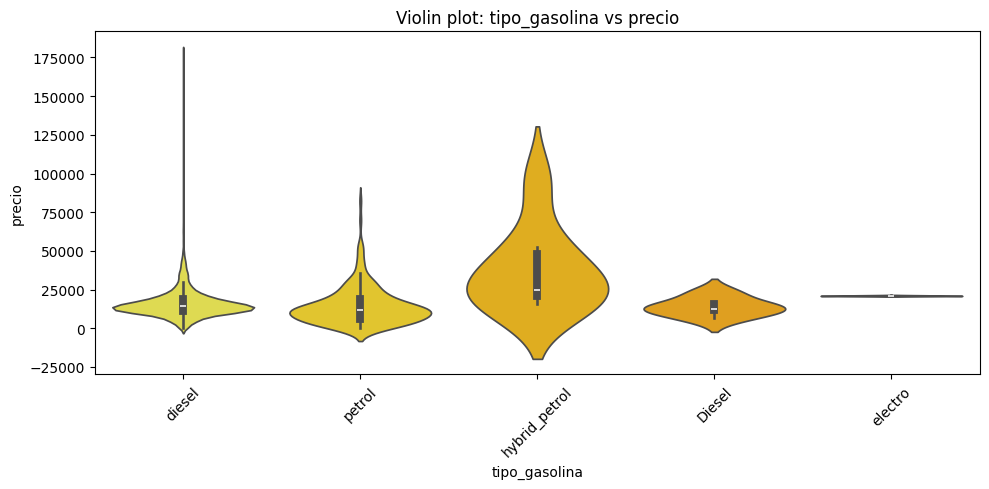

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


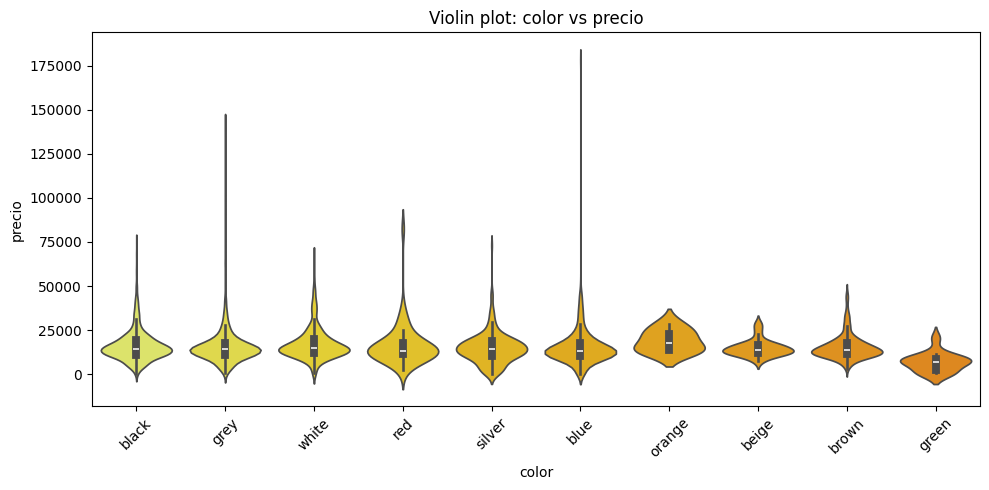

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


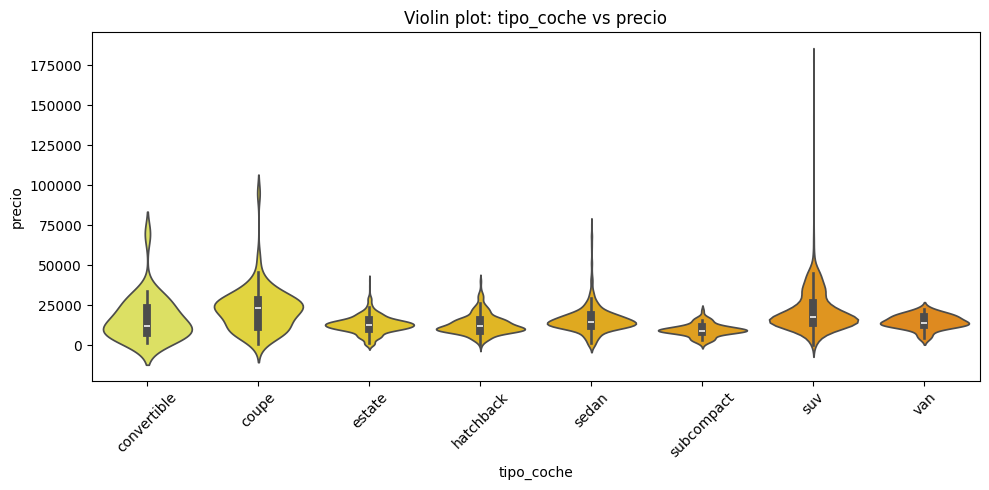

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


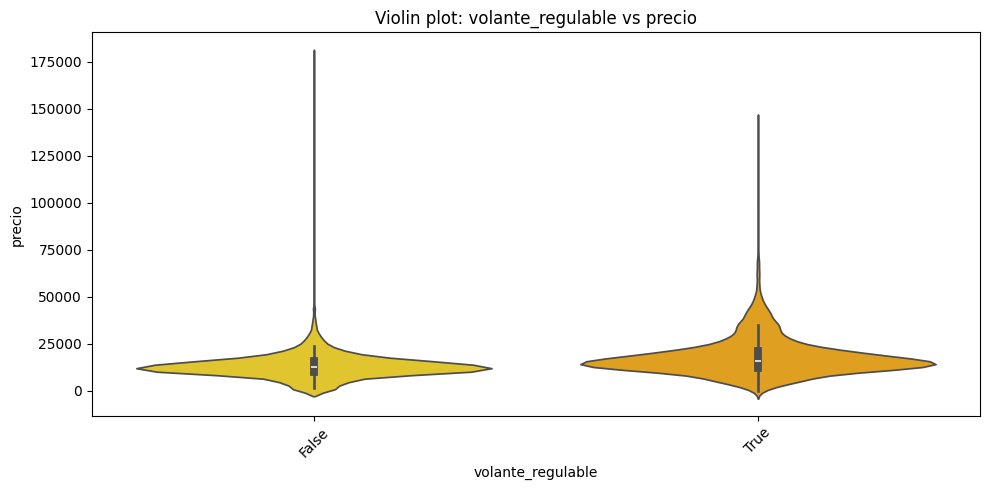

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


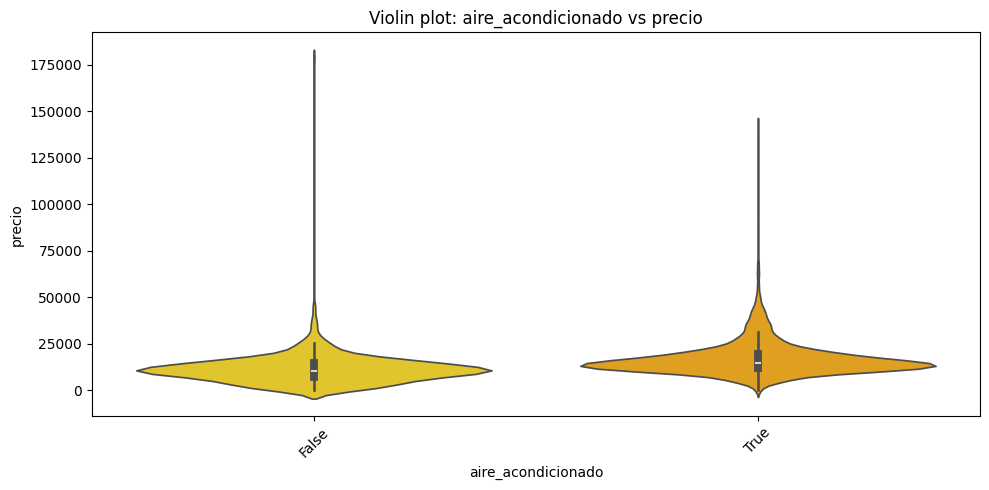

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


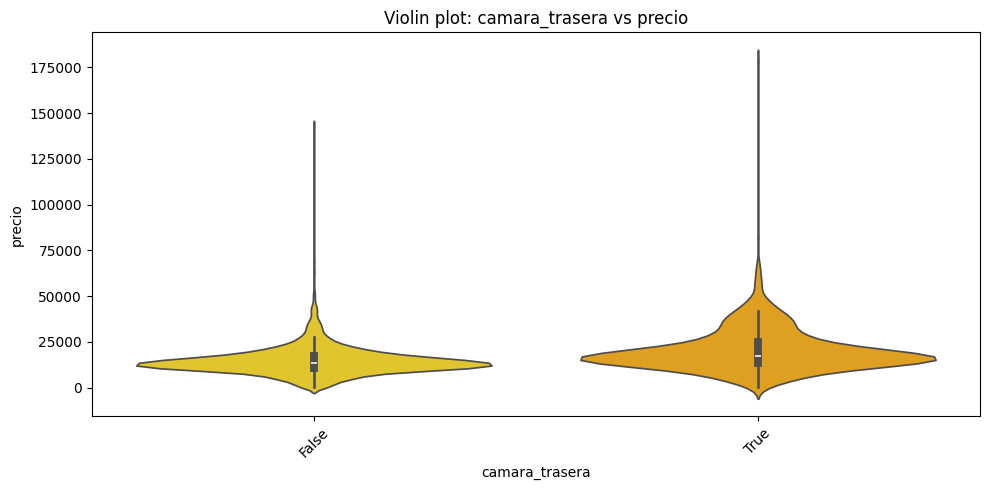

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


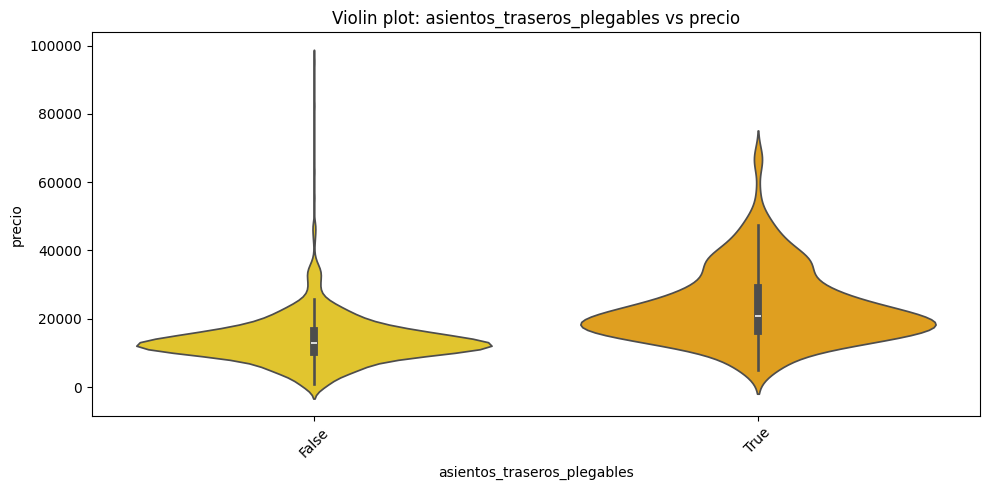

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


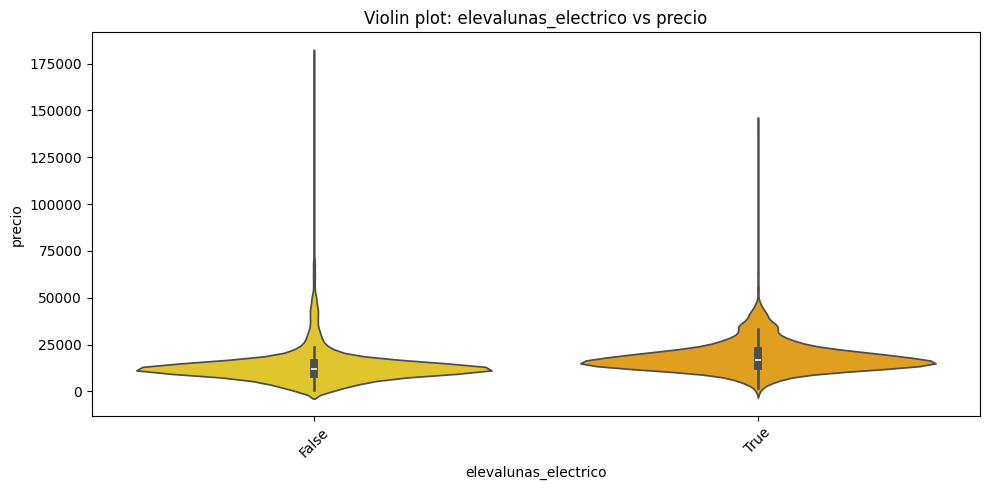

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


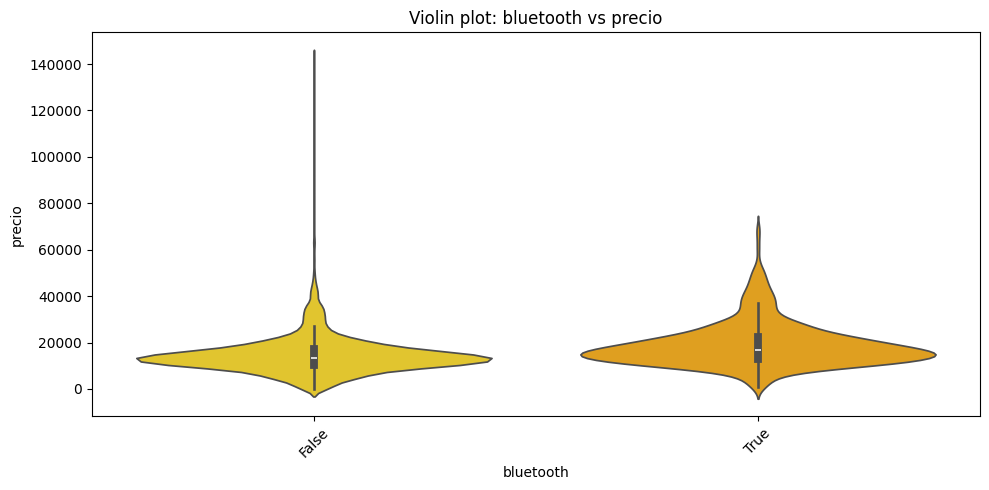

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


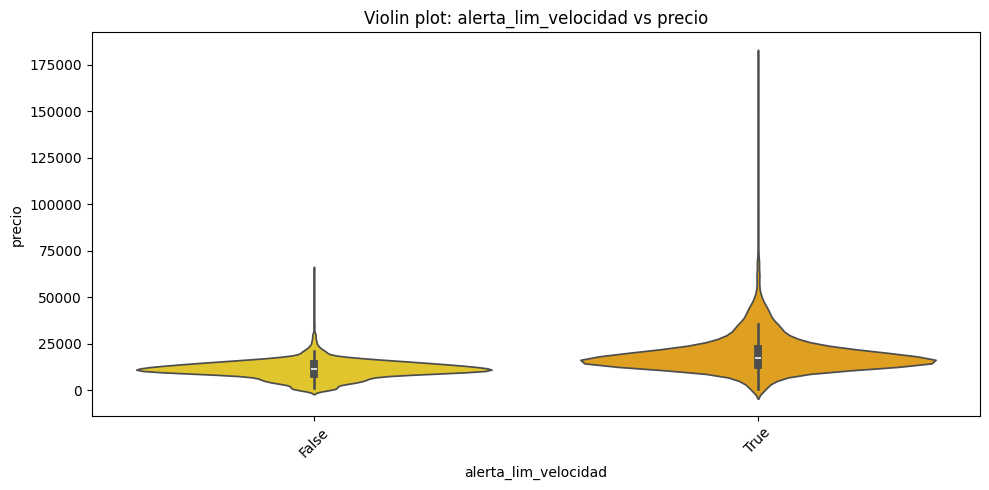

In [ ]:
## Kike Variables categoricas con target usando violinplot
## Kike Conclusion: Asientos plegables traseros más caros. Naranja, cuope e Hybrid-petrol más caro
## Kike Seleccionar columnas categóricas (object o category)
cat_cols = df_inicial_test.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.violinplot(
        x=df_inicial_test[col],
        y=df_inicial_test["precio"],
        palette="Wistia"
    )
    plt.title(f"Violin plot: {col} vs precio")
    plt.xlabel(col)
    plt.ylabel("precio")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## PREGUNTA 6

In [ ]:
## Kike 6. Transformación de categóricas a numéricas, ¿Qué variables van a transformar? ¿Que técnica se va usar?

In [ ]:
## Kike Miramos en un info como están las variables y después hacemos un bucle que me cambie todas las categóricas a numéricas

df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

In [ ]:
## Kike vuelvo a listar todas las variables con sus valores únicos
for i in df_inicial_test:
  print(i,"\n\n",df_inicial_test[i].value_counts(),"\n\n")

modelo 

 modelo
320                  752
520                  633
318                  568
X3                   438
116                  358
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 76, dtype: int64 


km 

 km
129317.0    2
129214.0    2
193202.0    2
72760.0     2
188713.0    2
           ..
193231.0    1
84058.0     1
303225.0    1
205603.0    1
87542.0     1
Name: count, Length: 4784, dtype: int64 


potencia 

 potencia
135.0    882
120.0    785
85.0     631
100.0    570
105.0    451
        ... 
412.0      1
0.0        1
423.0      1
300.0      1
261.0      1
Name: count, Length: 61, dtype: int64 


fecha_registro 

 fecha_registro
2013-07-01    93
2014-03-01    83
2014-05-01    81
2013-01-01    78
2013-10-01    77
              ..
2004-11-01     1
2009-12-01     1
2005-02-01     1
2004-06-01     1
2005-09-01     1
Name: count, Length: 180, dtype: int

In [ ]:
for i in df_inicial_test:
    print(df_inicial_test[i].dtype.kind)

O
f
f
M
O
O
O
O
O
O
O
O
O
O
f
M
M
i


In [ ]:
def obtener_lista_variables(dataset):

    lista_numericas=[]
    lista_boolean=[]
    lista_categoricas=[]

    for i in dataset:
        if    (dataset[i].dtype.kind=="f" or dataset[i].dtype.kind=="i") and len(dataset[i].unique())!=2 and (i not in target):
              lista_numericas.append(i)
        elif  (dataset[i].dtype.kind=="f" or dataset[i].dtype.kind=="i") and len(dataset[i].unique())==2 and (i not in target):
              lista_boolean.append(i)
        elif  (dataset[i].dtype.kind=="O") and i not in target:
              lista_categoricas.append(i)

    return lista_numericas, lista_boolean, lista_categoricas

In [ ]:
## Kike Paso al dataset las listas
lista_numericas, lista_boolean, lista_categoricas = obtener_lista_variables(df_inicial_test)

In [ ]:
print (lista_categoricas)

['modelo', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'alerta_lim_velocidad']


In [ ]:
## Kike Transformamos 11 variables categóricas
## Kike modelo (77), tipo gasolina (6), color (11), tipo coche(9), volante reg(T/F), Aire (T/F), Camara T(T/F), Asientos (T/F), elevalunas (T/F), bluetooth (T/F), Alerta (T/F)

In [ ]:
for col in lista_categoricas:
    print(f"Columna: {col}\n")
    print(df_inicial_test[col].value_counts(dropna=False))  # Incluye NaN
    print("\n" + "-"*50 + "\n")

Columna: modelo

modelo
320                  752
520                  633
318                  568
X3                   438
116                  358
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 77, dtype: int64

--------------------------------------------------

Columna: tipo_gasolina

tipo_gasolina
diesel           4631
petrol            191
hybrid_petrol       8
NaN                 5
Diesel              5
electro             3
Name: count, dtype: int64

--------------------------------------------------

Columna: color

color
black     1499
grey      1070
blue       647
white      484
NaN        445
brown      302
silver     292
red         47
beige       37
green       14
orange       6
Name: count, dtype: int64

--------------------------------------------------

Columna: tipo_coche

tipo_coche
NaN            1460
estate         1107
sedan           821
suv

In [ ]:
## Kike Quiero pasar las categoricas a numericas.
## Kike Primero paso las 7 variables T/F. Nos quedan 4 variables categóricas

cols_bool = ["volante_regulable", "aire_acondicionado", "camara_trasera", "asientos_traseros_plegables", "elevalunas_electrico", "bluetooth","alerta_lim_velocidad"]

for col in cols_bool:
    df_inicial_test[col] = np.where(df_inicial_test[col] == "TRUE", 1, 0)

In [ ]:
## Kike Creo que no me ha pasado a lista_numericas las 7 variables anteriores
## Kike Se puede hacer un ordinal encoder a tipo_gasolina, color y tipo_coche.
## Kike Pendiente de decidir que se hace con los 77 modelos.

Columna: modelo

modelo
320                  752
520                  633
318                  568
X3                   438
116                  358
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 77, dtype: int64

--------------------------------------------------

Columna: tipo_gasolina

tipo_gasolina
diesel           4631
petrol            191
hybrid_petrol       8
NaN                 5
Diesel              5
electro             3
Name: count, dtype: int64

--------------------------------------------------

Columna: color

color
black     1499
grey      1070
blue       647
white      484
NaN        445
brown      302
silver     292
red         47
beige       37
green       14
orange       6
Name: count, dtype: int64

--------------------------------------------------

Columna: tipo_coche

tipo_coche
NaN            1460
estate         1107
sedan           821
suv

In [ ]:
df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4843 non-null   int64         
 8   aire_acondicionado           4843 non-null   int64         
 9   camara_trasera               4843 non-null   int64         
 10  asientos_traseros_plegables  4843 non-null   int64         
 11  elevalunas_electrico         4843 non-null 

## PREGUNTA 7

In [ ]:
## 7. Escalar variables (usando minmaxscaler) y luego aplicar la correlación final de variables ¿Hay alguna variable finalmente correlacionada?

## PREGUNTA 8

In [ ]:
## 8. Subir un pantallazo con el nombre de TODAS las columnas que tiene el dataframe final final vfin y el tipo de dato que tiene, tip lo más sencillo es hacer un .info al dataframe y tomarle un pantallazo y subirlo, importante deben aparecer TODAS las columnas

In [ ]:
## Es hacer un pantallazo del data frame y del .info y subirlo al enlance.

##PREGUNTA 9

In [ ]:
## 9. Exportar en un excel de las primeras 50 filas del dataset (df.to_excel(...)

In [ ]:
pd.to_excel(df_final,"/content/drive/MyDrive/Colab Notebooks/df_final")

## PREGUNTA 10

In [ ]:
## 10. Sube el programa (el archivo .ipynb, NO EL PICKLE de lo contrario me quedaré sin espacio...) y con esto hemos terminado ;)

In [ ]:
# En archivo voy a descargar .ipynb. Luego lo subo al enlace